In [1]:
! pip install pypsa highspy

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import sys
import os

ROOT_DIR = os.getcwd()
PROJECT_DIR = os.path.join(ROOT_DIR, "drive/MyDrive/Colab_Notebooks/PyPSA/Zonal_model/data/")
sys.path.append(PROJECT_DIR)

## Import data

Now that the `input_data_utils.py` file has been created, you can import it into other notebooks like this:

1.  **Mount Google Drive** (if not already mounted in the new notebook):

    ```python
    from google.colab import drive
    drive.mount('/content/drive')
    ```

2.  **Add the project directory to your Python path** so you can import modules from it:

    ```python
    import sys
    import os

    ROOT_DIR = os.getcwd()
    PROJECT_DIR = os.path.join(ROOT_DIR, "drive/MyDrive/Colab_Notebooks/PyPSA/Zonal_model/data/")
    sys.path.append(PROJECT_DIR)
    ```

3.  **Import the module and access its variables**:

    ```python
    import input_data_utils

    # The variables will be available within the imported module's namespace
    # For example, to access loaded_data, you would use:
    # print(input_data_utils.loaded_data)

    # If you want to use the variables directly in your current notebook's scope,
    # you can assign them like this:
    # my_loaded_data = input_data_utils.loaded_data
    # my_optimization_inputs = input_data_utils.optimization_inputs
    # my_elec_generators = input_data_utils.elec_generators

    # Or, you can import specific items directly (though 'from ... import *' is generally discouraged)
    # from input_data_utils import loaded_data, optimization_inputs, elec_generators
    ```

This will allow you to reuse the data loading logic and variables in any other Colab notebook.

In [4]:
# Import packages
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pypsa
import input_data_utils

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Successfully loaded data from /content/drive/MyDrive/Colab_Notebooks/PyPSA/Zonal_model/data/input_data.json:


In [5]:
optimization_inputs = input_data_utils.loaded_data.get('optimization_inputs')
elec_generators = input_data_utils.loaded_data.get('elec_generators')

In [6]:
elec_generators

{'Solar': {'p_nom': 5250.0, 'marginal_cost': 0.01, 'carrier': 'solar'},
 'Nuclear': {'p_nom': 696.0, 'marginal_cost': 12.0, 'carrier': 'nuclear'},
 'Hydro': {'p_nom': 1228.9, 'marginal_cost': 0.5, 'carrier': 'hydro'},
 'Coal': {'p_nom': 540.0, 'marginal_cost': 95.0, 'carrier': 'coal'},
 'Wind': {'p_nom': 305.5, 'marginal_cost': 0.01, 'carrier': 'wind'}}

In [7]:
# Original capacities for earlier cases:
p_wind_nom = 2000
p_SMR_nom = 400

In [8]:
input_profiles_path = PROJECT_DIR + 'input_profiles.csv'

try:
  input_profiles = pd.read_csv(input_profiles_path, index_col=0, parse_dates=True)

  print("Input_profiles loaded.")
except FileNotFoundError:
  print(f"Error: The file {input_profiles_path} was not found. Please ensure it exists.")
except Exception as e:
  print(f"An error occurred while loading input_profiles: {e}")

Input_profiles loaded.


## Hydrogen and Gas Demand

In [9]:
import pandas as pd
import numpy as np

# 1. Use the same snapshots
period_snapshots = input_profiles.loc['2040-09-10':'2040-09-17'].index

# 2. Define multi-carrier Daily Requests (MWh/day)
# H2: Original (Peak on 12/13), CH4: Swapped (Peak on 14/15)
daily_requests = {
    'H2': {
        '2040-09-10': 12000, '2040-09-11': 12000, '2040-09-12': 15000,
        '2040-09-13': 15000, '2040-09-14': 10000, '2040-09-15': 10000,
        '2040-09-16': 13000, '2040-09-17': 13000
    },
    'CH4': {
        '2040-09-10': 13000, '2040-09-11': 13650, '2040-09-12': 9425,
        '2040-09-13': 11375, '2040-09-14': 14625, '2040-09-15': 14625,
        '2040-09-16': 13325, '2040-09-17': 13325
    }
}

# 3. Create hourly time-series for both
h2_demand_hourly = pd.Series(0.0, index=period_snapshots)
ch4_demand_hourly = pd.Series(0.0, index=period_snapshots)

# Process H2
for date, mwh_day in daily_requests['H2'].items():
    h2_demand_hourly.loc[date] = mwh_day / 24.0

# Process CH4
for date, mwh_day in daily_requests['CH4'].items():
    ch4_demand_hourly.loc[date] = mwh_day / 24.0

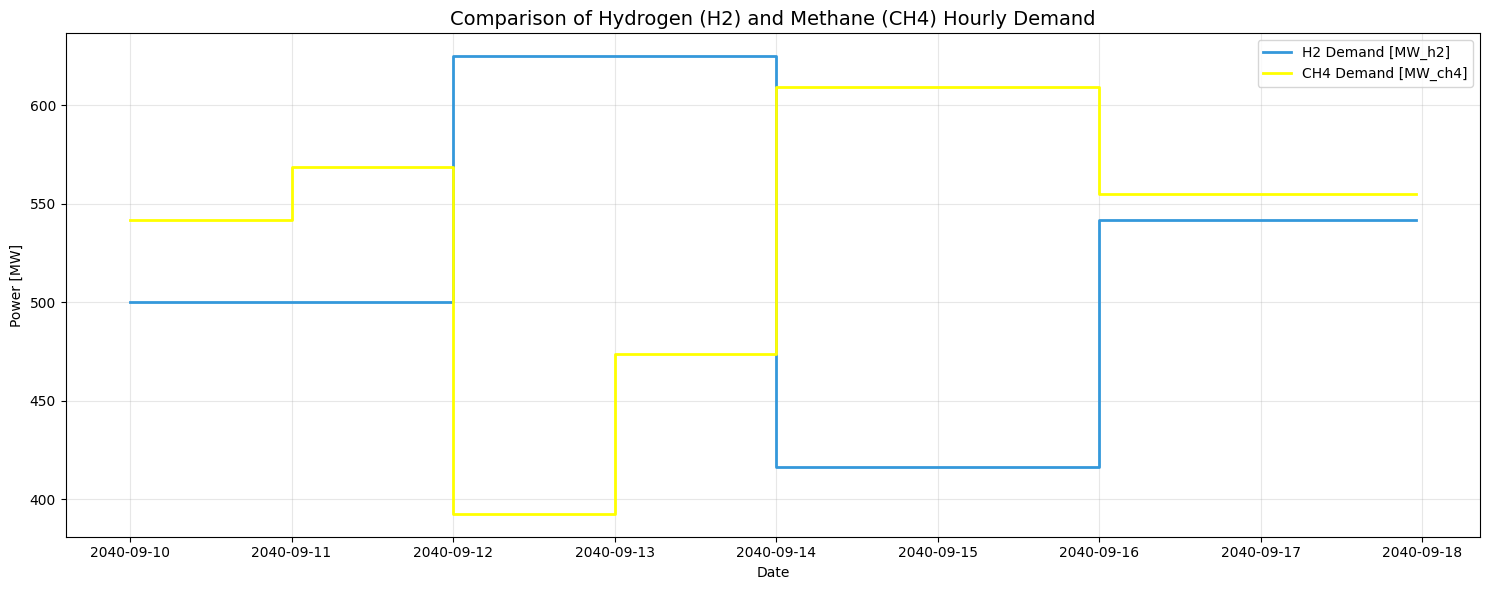

In [10]:
import matplotlib.pyplot as plt

# Create the plot
plt.figure(figsize=(15, 6))

# Plot H2 Demand
plt.step(h2_demand_hourly.index, h2_demand_hourly.values, where='post', label='H2 Demand [MW_h2]', color='#3498db', linewidth=2)

# Plot CH4 Demand
plt.step(ch4_demand_hourly.index, ch4_demand_hourly.values, where='post', label='CH4 Demand [MW_ch4]', color='yellow', linewidth=2)

# Formatting
plt.title('Comparison of Hydrogen (H2) and Methane (CH4) Hourly Demand', fontsize=14)
plt.ylabel('Power [MW]')
plt.xlabel('Date')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Case H.1 : Basic Hydrogen Market - Import and Decoupled Electrolyzer

**Case H.1** represents a Basic Hydrogen Market with the following characteristics:

**Decoupled Wind Farm**: A wind farm connected to a private bus, supply the electrolyzer only and cannot sell electricity to the main grid.

**Dedicated Electrolyzer**: Converts the wind energy into hydrogen with defined efficiency.

**Hydrogen Imports**: Acts as the 'swing' producer to meet any demand not covered by the wind-powered electrolyzer, at a fixed cost.

**Fixed Demand**: A time-varying hourly load based on daily requests.


In this setup, the hydrogen price is set by the wind generation (cheap) when it's available and by imports (expensive) when wind is insufficient.

In [11]:

# 1. Setup snapshots (same as your previous cases)
n_h1 = pypsa.Network()
n_h1.set_snapshots(period_snapshots)

# 2. Add Buses
n_h1.add("Bus", "Main_Grid", carrier="AC")  # The electricity market
n_h1.add("Bus", "H2_Market", carrier="H2")  # The hydrogen market
n_h1.add("Bus", "Wind_Dedicated_Bus", carrier="AC") # Private bus for decoupling

# 3. Add the "Decoupled" Wind Farm
# This wind farm is NOT connected to the Main_Grid.
# It can only feed the dedicated electrolyzer.
n_h1.add("Generator", "Wind",
      bus="Wind_Dedicated_Bus",
      p_nom=p_wind_nom, # Capacity in MW
      p_max_pu=input_profiles.loc[period_snapshots, 'df_wind'], # Use your wind profile
      marginal_cost=5.0)

# 4. Add the Decoupled Electrolyzer
# Links the private wind bus to the H2 Market
n_h1.add("Link", "Electrolyzer_Decoupled",
      bus0="Wind_Dedicated_Bus",
      bus1="H2_Market",
      p_nom=p_wind_nom,
      efficiency=0.7)

# 5. Add Hydrogen Imports
# This represents H2 coming from outside the system (e.g., pipelines or ships)
# The marginal_cost here represents the "Import Price"
n_h1.add("Generator", "H2_Import",
      bus="H2_Market",
      p_nom_extendable=True, # Allow the model to import as much as needed
      marginal_cost=68,      # Price in EUR/MWh_h2
      carrier="H2")

# 6. Add Daily Hydrogen Demand
# (Using the daily_requests logic from the previous step)
n_h1.add("Load", "H2_Demand",
      bus="H2_Market",
      p_set=h2_demand_hourly) # The hourly profile created previously

In [12]:
# Optimization - Case 1
result_h1 = n_h1.optimize(solver_name='highs', include_objective_constant=False)

Index(['Main_Grid', 'H2_Market', 'Wind_Dedicated_Bus'], dtype='object', name='name')
Index(['H2_Import'], dtype='object', name='name')
Index(['Electrolyzer_Decoupled'], dtype='object', name='name')


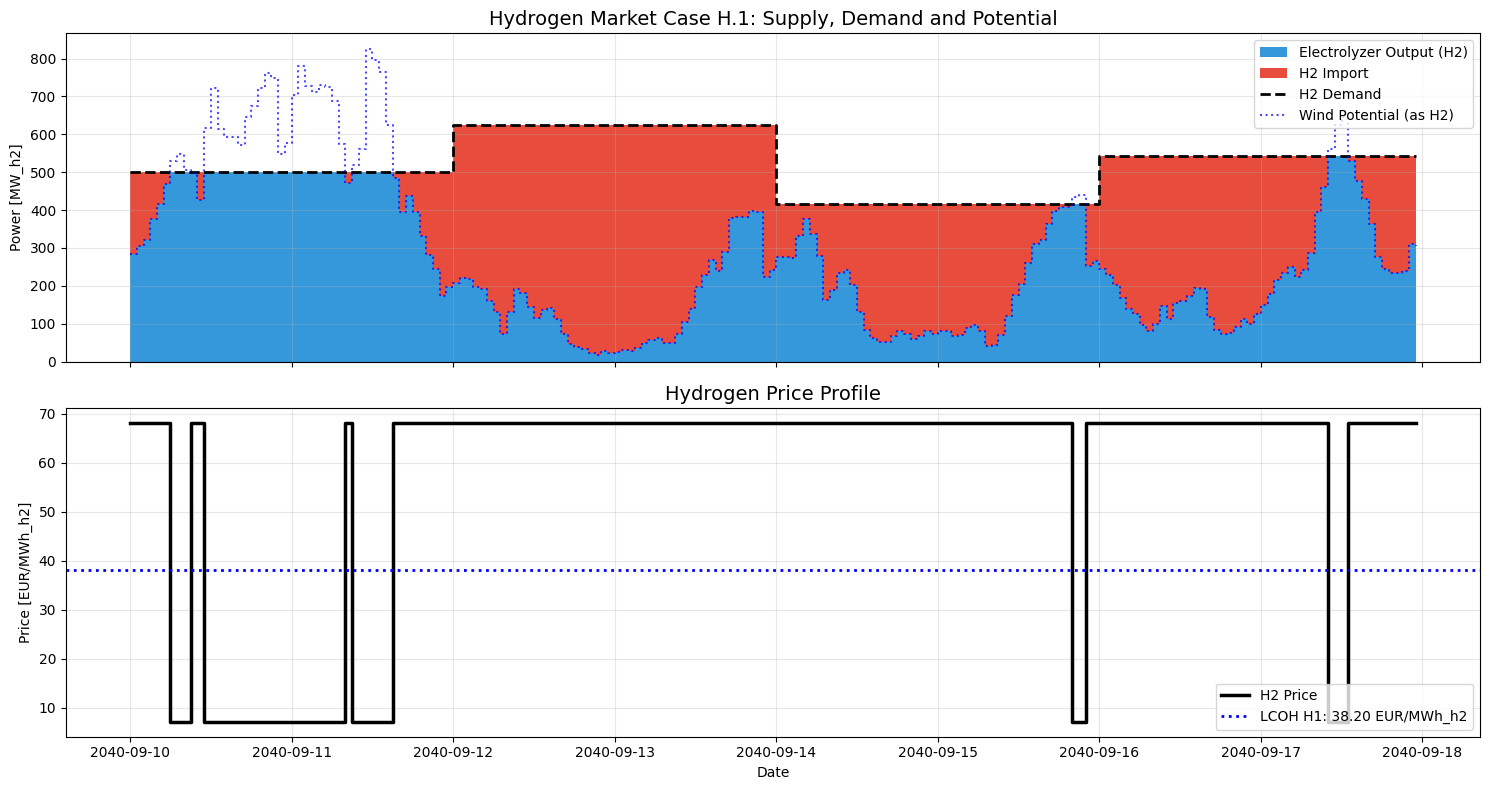

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# --- Extract required Hydrogen data from the network n_h1 ---
h2_import_prof = n_h1.generators_t.p['H2_Import']
electrolyzer_prof = n_h1.links_t.p1['Electrolyzer_Decoupled'].abs()
h2_load_prof = n_h1.loads_t.p['H2_Demand']

# Calculate Wind Potential (p_nom * p_max_pu)
# Note: This is the AC potential before electrolyzer efficiency
wind_p_nom = n_h1.generators.at['Wind', 'p_nom']
wind_potential_ac = n_h1.generators_t.p_max_pu['Wind'] * wind_p_nom
# Convert potential to H2 equivalent to compare with output (Potential * Efficiency)
wind_potential_h2 = wind_potential_ac * n_h1.links.at['Electrolyzer_Decoupled', 'efficiency']

# Extract marginal price (Hydrogen price) at the H2_Market bus
h2_price = n_h1.buses_t.marginal_price['H2_Market']

# Calculate average marginal price for H2
total_cost_h1 = n_h1.objective
total_h2_demand = n_h1.loads_t.p['H2_Demand'].sum()
LCOH_h1_price = total_cost_h1 / total_h2_demand

# Create a figure with 2 subplots
fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

# 1. H2 Supply and Demand Profile
y_stack_h2 = [electrolyzer_prof.values, h2_import_prof.values]
labels_h2 = ['Electrolyzer Output (H2)', 'H2 Import']
colors_h2 = ['#3498db', '#e74c3c']

axes[0].stackplot(h2_load_prof.index, y_stack_h2, labels=labels_h2, colors=colors_h2, step='post', alpha=1.0)

# Plot H2 Demand
axes[0].step(h2_load_prof.index, h2_load_prof.values, where='post', color='black', linestyle='--', linewidth=2, label='H2 Demand')

# Plot Wind Potential (converted to H2 equivalent)
axes[0].step(wind_potential_h2.index, wind_potential_h2.values, where='post', color='blue', linestyle=':', alpha=0.7, label='Wind Potential (as H2)')

axes[0].axhline(0, color='black', linewidth=0.8, alpha=0.5)
axes[0].set_title('Hydrogen Market Case H.1: Supply, Demand and Potential', fontsize=14)
axes[0].set_ylabel('Power [MW_h2]')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# 2. Hydrogen Price - CHANGED TO BLACK
axes[1].step(h2_price.index, h2_price.values, where='post', color='black', linewidth=2.5, label='H2 Price')
axes[1].axhline(LCOH_h1_price, color='blue', linestyle=':', linewidth=2, label=f'LCOH H1: {LCOH_h1_price:,.2f} EUR/MWh_h2')
axes[1].set_title('Hydrogen Price Profile', fontsize=14)
axes[1].set_ylabel('Price [EUR/MWh_h2]')
axes[1].set_xlabel('Date')
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
import plotly.graph_objects as go

# Calculate total energy flows (MWh) for the period
wind_to_elec = n_h1.links_t.p0['Electrolyzer_Decoupled'].sum()
elec_to_h2 = n_h1.links_t.p1['Electrolyzer_Decoupled'].abs().sum()
import_to_h2 = n_h1.generators_t.p['H2_Import'].sum()

# Energy loss in electrolysis
elec_loss = wind_to_elec - elec_to_h2

# Define Sankey diagram nodes and links
# Nodes: 0: Wind, 1: Electrolyzer, 2: H2 Demand (Merged), 3: H2 Import, 4: Conversion Loss
# Reordering links to influence the stack (Elec/Wind first)
fig = go.Figure(data=[go.Sankey(
    node = dict(
      pad = 15,
      thickness = 20,
      line = dict(color = "black", width = 0.5),
      label = ["Wind Farm (Dedicated)", "Electrolyzer", "H2 Demand", "H2 Import", "Conversion Loss"],
      color = ["skyblue", "#3498db", "#e67e22", "#e74c3c", "#95a5a6"]
    ),
    link = dict(
      source = [0, 1, 3, 1],
      target = [1, 2, 2, 4],
      value = [wind_to_elec, elec_to_h2, import_to_h2, elec_loss]
  ))])

fig.update_layout(
    title=dict(
        text="Case H.1: Hydrogen Energy Flow (Merged Sink) - [MWh]",
        font=dict(size=14)
    )
)
fig.show()

**Summary: Case H.1 - Basic Hydrogen Market**

In this basic configuration, the system consists of:
*   **Dedicated Wind Farm**: Can only supply the electrolyzer.
*   **Dedicated Electrolyzer (70% efficiency)**: Converts wind energy to H2.
*   **H2 Imports**: Available at a fixed price to meet the remaining demand.
*   **No Storage**: Production must match demand in real-time or be supplemented by imports.

**Price Analysis: Arithmetic vs. Weighted Average**
1. **LCOH**. The average price is ratio between Total Cost (n_h1.objective), as the sum of all marginal costs multiplied by the generation at each hour and the sum of all hydrogen loads over the simulated period.
The Calculation:

**avg_h2_price = total_cost_h1 / total_h2_demand**

This represents the Levelized Cost of Hydrogen (LCOH) for this specific system configuration, showing the average cost to produce and import every MWh needed to meet the demand.

2. **Marginal Price**. In energy market modeling, we distinguish between two ways of looking at the 'average' price of marginal price:

**System Price**: $\frac{\sum \text{Price}_t}{N}$. It reflects the average state of the market bus.

**Weighted Average**: $\frac{\sum (\text{Price}_t \times \text{Demand}_t)}{\sum \text{Demand}_t}$. It reflects the actual cost paid per unit of energy consumed.

In [15]:
import pandas as pd

# Data from Case H.3 (n_h3)
h2_prices = n_h1.buses_t.marginal_price['H2_Market']
h2_demand = n_h1.loads_t.p['H2_Demand']

# 1. Average System Price (Arithmetic Mean)
simple_avg = h2_prices.mean()

# 2. Pondered Marginal Price / Operational LCOH
total_cost = (h2_prices * h2_demand).sum()
total_volume = h2_demand.sum()
weighted_avg = total_cost / total_volume

# Create Comparison Table
comparison_df = pd.DataFrame({
    'Price Metric': [
        'LCOH',
        'Average System Price',
        'Pondered Marginal Price'
    ],
    'Value [EUR/MWh]': [
        f"{LCOH_h1_price:.2f}",
        f"{simple_avg:.2f}",
        f"{weighted_avg:.2f}"
    ],
    'Description': [
        'The levelised cost of hydrogen',
        'Mean of all hourly prices',
        'The actual cost paid per MWh for volume consumed'
    ]
})

# Display cleaned table without index
display(comparison_df.style.hide(axis='index'))

Price Metric,Value [EUR/MWh],Description
LCOH,38.20,The levelised cost of hydrogen
Average System Price,56.91,Mean of all hourly prices
Pondered Marginal Price,57.38,The actual cost paid per MWh for volume consumed


In [16]:
import pandas as pd

# Extract Case H.1 results
total_demand_h1 = n_h1.loads_t.p['H2_Demand'].sum()
elec_output_h1 = n_h1.links_t.p1['Electrolyzer_Decoupled'].abs().sum()
imports_h1 = n_h1.generators_t.p['H2_Import'].sum()

# Create the simplified three-row summary
h1_summary_data = {
    'Metric': ['Total H2 Demand', 'Green H2 (Electrolyzer)', 'H2 Imports'],
    'Value': [
        f"{total_demand_h1:,.0f} MWh",
        f"{ (elec_output_h1/total_demand_h1)*100:.1f}%",
        f"{ (imports_h1/total_demand_h1)*100:.1f}%"
    ]
}

df_h1_simple = pd.DataFrame(h1_summary_data)

# Hide the index (row numbers) for a cleaner display
display(df_h1_simple.style.hide(axis='index'))

Metric,Value
Total H2 Demand,"100,000 MWh"
Green H2 (Electrolyzer),49.0%
H2 Imports,51.0%


## Case H.2 : Hydrogen market - Import, Green Hydrogen and SMR

Case H.2 expands on the basic market by adding a second production technology: Steam Methane Reforming (SMR). Here are the key characteristics:

**Diversified Supply**: In addition to the Green Hydrogen (from the wind-powered electrolyzer) and Direct Imports, it introduces Blue Hydrogen via an SMR plant.

**CH4 Infrastructure**: Adds a Methane (CH4) bus and a CH4 import generator to fuel the SMR.

**Merit Order Dynamics**: This case demonstrates how different technologies compete. Usually, Green H2 (low marginal cost) is used first, followed by SMR, and finally expensive H2 Imports as the last resort.

**Price Discovery**: The marginal price of hydrogen at the H2_Market bus now fluctuates between the cost of wind-electrolysis, SMR production, and H2 imports depending on wind availability.

In [17]:
# 1. Network H2
n_h2 = pypsa.Network()
n_h2.set_snapshots(period_snapshots)

# 2. Add Buses - Local electricity, CH4 and H2
n_h2.add("Bus", "H2_Market", carrier="H2")
n_h2.add("Bus", "Wind_Dedicated_Bus", carrier="AC")
n_h2.add("Bus", "CH4_Grid",carrier="CH4")

# 3. Add Electricity Part - Wind generation and Electrolyzer
n_h2.add("Generator", "Wind",
      bus="Wind_Dedicated_Bus",
      p_nom=p_wind_nom,
      p_max_pu=input_profiles.loc[period_snapshots, 'df_wind'],
      marginal_cost=5.0)

n_h2.add("Link", "Electrolyzer_Decoupled",
      bus0="Wind_Dedicated_Bus",
      bus1="H2_Market",
      p_nom=p_wind_nom,
      efficiency=0.7)

# Hydrogen Part - Import and Demand
n_h2.add("Generator", "H2_Import",
      bus="H2_Market",
      p_nom_extendable=True,
      marginal_cost=68,
      carrier="H2")

n_h2.add("Load", "H2_Demand",
      bus="H2_Market",
      p_set=h2_demand_hourly)


# CH4 Part - Import and Steam Methane Reforming
n_h2.add("Generator", "CH4_Import",
       bus="CH4_Grid",
       p_nom_extendable=True,
       marginal_cost=40)

n_h2.add("Link", "SMR_Plant",
       bus0="CH4_Grid",
       bus1="H2_Market",
       p_nom=p_SMR_nom,
       p_min_pu=0.4,           # 40% minimum load
       ramp_limit_up=0.2,      # 20% of capacity per hour
       ramp_limit_down=0.2,
       efficiency=0.75,
       marginal_cost=1)

# --- Sanitize to define carriers and remove warnings ---
n_h2.sanitize()

# 5. Optimize Case H.2
n_h2.optimize(solver_name='highs', include_objective_constant=False)


('ok', 'optimal')

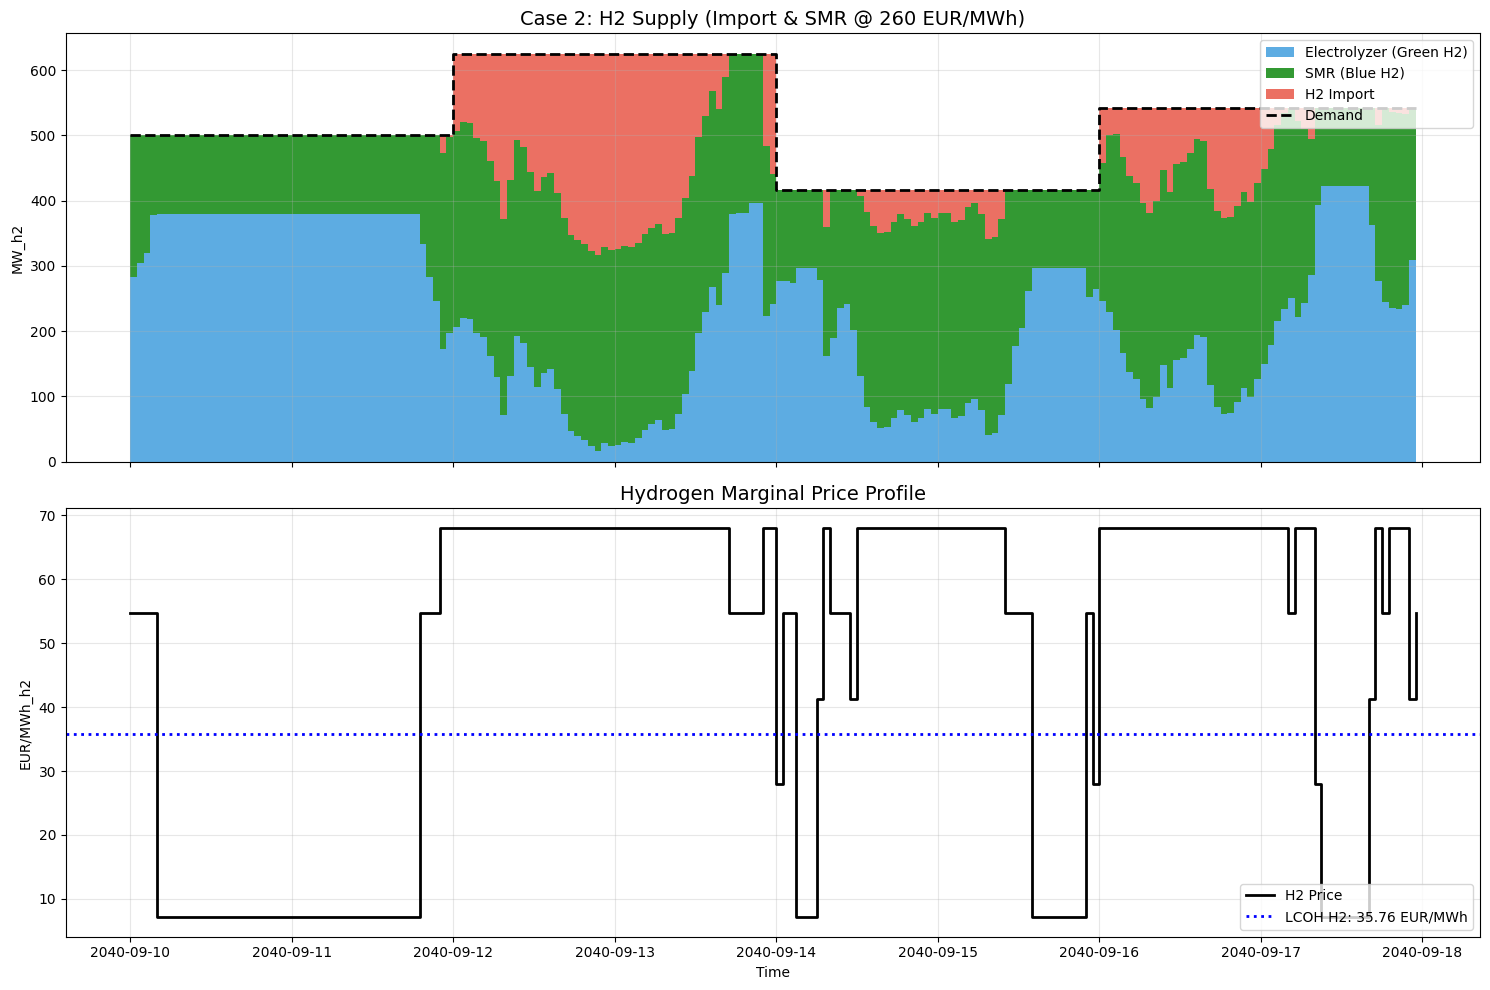

In [18]:
import matplotlib.pyplot as plt

# Extract Case 2 Results
h2_import_h2 = n_h2.generators_t.p['H2_Import']
electrolyzer_h2 = n_h2.links_t.p1['Electrolyzer_Decoupled'].abs()
smr_h2 = n_h2.links_t.p1['SMR_Plant'].abs()
h2_load = n_h2.loads_t.p['H2_Demand']
h2_price = n_h2.buses_t.marginal_price['H2_Market']

total_cost_h2 = n_h2.objective
total_h2_demand = n_h2.loads_t.p['H2_Demand'].sum()
LCOH_h2_price = total_cost_h2 / total_h2_demand

# Create Visualization
fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

# 1. Supply & Demand Stack
labels = ['Electrolyzer (Green H2)', 'SMR (Blue H2)', 'H2 Import']
colors = ['#3498db', 'green', '#e74c3c']
axes[0].stackplot(h2_load.index, [electrolyzer_h2, smr_h2, h2_import_h2], labels=labels, colors=colors, alpha=0.8, step='post')
axes[0].step(h2_load.index, h2_load, where='post', color='black', linestyle='--', linewidth=2, label='Demand')
axes[0].set_title('Case 2: H2 Supply (Import & SMR @ 260 EUR/MWh)', fontsize=14)
axes[0].set_ylabel('MW_h2')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# 2. Marginal Prices
axes[1].step(h2_price.index, h2_price, where='post', color='black', linewidth=2, label='H2 Price')
axes[1].axhline(LCOH_h2_price, color='blue', linestyle=':', linewidth=2, label=f'LCOH H2: {LCOH_h2_price.mean():.2f} EUR/MWh')
axes[1].set_title('Hydrogen Marginal Price Profile', fontsize=14)
axes[1].set_ylabel('EUR/MWh_h2')
axes[1].set_xlabel('Time')
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

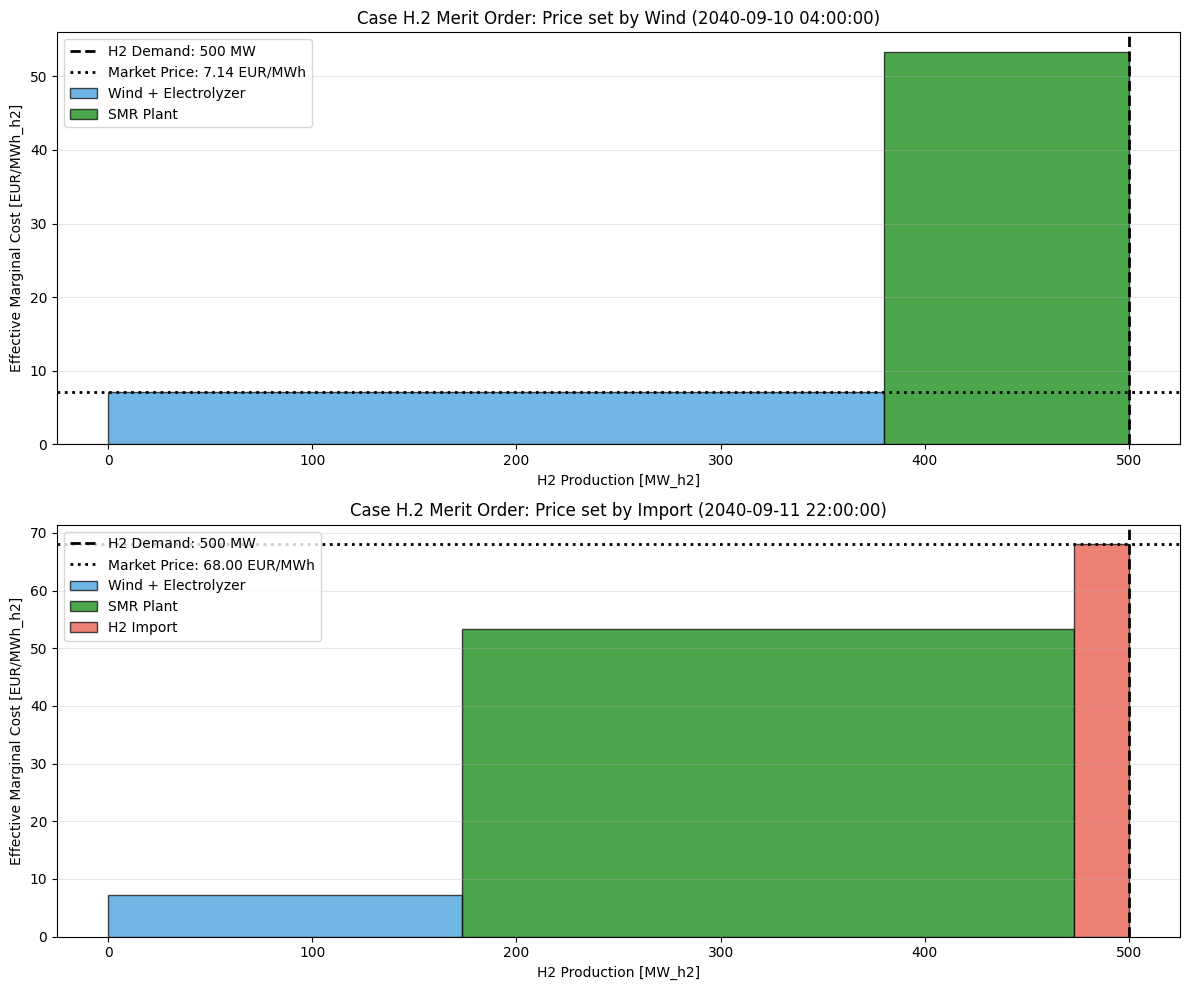

In [19]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Identify two distinct snapshots from n_h2 results
h2_prices = n_h2.buses_t.marginal_price['H2_Market']

# Snapshot where price is low (determined by Wind/Electrolyzer ~7.14)
low_price_val = h2_prices.min()
low_price_time = h2_prices[h2_prices == low_price_val].index[0]

# Snapshot where price is high (determined by Import/SMR = 68.0)
high_price_val = h2_prices.max()
high_price_time = h2_prices[h2_prices == high_price_val].index[0]

def plot_h2_merit_order(network, snapshot, ax, title):
    # Calculate effective marginal costs for H2 supply components
    wind_eff_cost = network.generators.at['Wind', 'marginal_cost'] / network.links.at['Electrolyzer_Decoupled', 'efficiency']
    import_cost = network.generators.at['H2_Import', 'marginal_cost']
    smr_eff_cost = network.generators.at['CH4_Import', 'marginal_cost'] / network.links.at['SMR_Plant', 'efficiency']

    data = [
        {'name': 'Wind + Electrolyzer', 'cost': wind_eff_cost, 'dispatch': abs(network.links_t.p1.loc[snapshot, 'Electrolyzer_Decoupled'])},
        {'name': 'SMR Plant', 'cost': smr_eff_cost, 'dispatch': abs(network.links_t.p1.loc[snapshot, 'SMR_Plant'])},
        {'name': 'H2 Import', 'cost': import_cost, 'dispatch': network.generators_t.p.loc[snapshot, 'H2_Import']}
    ]

    df_mo = pd.DataFrame(data).sort_values(by='cost')
    df_mo['cum_dispatch'] = df_mo['dispatch'].cumsum()
    df_mo['prev_cum'] = df_mo['cum_dispatch'].shift(1, fill_value=0)

    colors = ['#3498db', 'green', '#e74c3c']
    for i, row in df_mo.iterrows():
        if row['dispatch'] > 0.1:
            ax.bar(row['prev_cum'], row['cost'], width=row['dispatch'],
                   align='edge', label=row['name'], color=colors[i % len(colors)],
                   alpha=0.7, edgecolor='black')

    load_val = network.loads_t.p.loc[snapshot, 'H2_Demand']
    ax.axvline(load_val, color='black', linestyle='--', linewidth=2, label=f'H2 Demand: {load_val:.0f} MW')

    sys_price = network.buses_t.marginal_price.at[snapshot, 'H2_Market']
    ax.axhline(sys_price, color='black', linestyle=':', linewidth=2, label=f'Market Price: {sys_price:.2f} EUR/MWh')

    ax.set_title(title)
    ax.set_xlabel('H2 Production [MW_h2]')
    ax.set_ylabel('Effective Marginal Cost [EUR/MWh_h2]')
    ax.legend(loc='upper left')
    ax.grid(axis='y', alpha=0.3)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

plot_h2_merit_order(n_h2, low_price_time, ax1, f"Case H.2 Merit Order: Price set by Wind ({low_price_time})")
plot_h2_merit_order(n_h2, high_price_time, ax2, f"Case H.2 Merit Order: Price set by Import ({high_price_time})")

plt.tight_layout()
plt.show()

In [20]:
import plotly.graph_objects as go

# 1. Calculate energy flows (MWh) for Case H.2
wind_to_elec = n_h2.links_t.p0['Electrolyzer_Decoupled'].sum()
elec_to_h2 = n_h2.links_t.p1['Electrolyzer_Decoupled'].abs().sum()
ch4_to_smr = n_h2.links_t.p0['SMR_Plant'].sum()
smr_to_h2 = n_h2.links_t.p1['SMR_Plant'].abs().sum()
import_to_h2 = n_h2.generators_t.p['H2_Import'].sum()
h2_to_demand = n_h2.loads_t.p['H2_Demand'].sum()

# Calculate losses
elec_loss = wind_to_elec - elec_to_h2
smr_loss = ch4_to_smr - smr_to_h2

# 2. Define Nodes and Links
fig = go.Figure(data=[go.Sankey(
    node = dict(
      pad = 15,
      thickness = 20,
      line = dict(color = "black", width = 0.5),
      label = ["Wind Farm", "CH4 Grid", "Electrolyzer", "SMR Plant", "H2 Demand", "H2 Import", "Conversion Losses"],
      color = ["skyblue", "orange", "#3498db", "green", "#e67e22", "#e74c3c", "#95a5a6"]
    ),
    link = dict(
      source = [0, 1, 2, 3, 5, 2, 3],
      target = [2, 3, 4, 4, 4, 6, 6],
      value = [wind_to_elec, ch4_to_smr, elec_to_h2, smr_to_h2, import_to_h2, elec_loss, smr_loss]
  ))])

fig.update_layout(
    title=dict(
        text="Case H.2: Hydrogen Energy Flow (Merged Sink) - [MWh]",
        font=dict(size=14)
    )
)
fig.show()

**Summary: Case H.2 - Hydrogen Market with SMR**

This configuration introduces a second production technology to the mix:
*   **Green H2 (Electrolyzer)**: Remains the cheapest source, covering the base load when wind is available.
*   **Blue H2 (SMR Plant)**: Adds a mid-range supply option using Methane (CH4). It is more expensive than wind but significantly cheaper than direct imports.
*   **Reduced Imports**: Imports now only act as the final 'peak' supply, dropping from 51% in Case H.1 to only 19% here.
*   **Price Competition**: The marginal price now fluctuates between the cost of Wind-H2 and SMR-H2, leading to a lower overall average cost for the system.

In [21]:
import pandas as pd

# Extract Case H.2 results
total_demand_h2 = n_h2.loads_t.p['H2_Demand'].sum()
elec_output_h2 = n_h2.links_t.p1['Electrolyzer_Decoupled'].abs().sum()
smr_output_h2 = n_h2.links_t.p1['SMR_Plant'].abs().sum()
imports_h2 = n_h2.generators_t.p['H2_Import'].sum()

# Create the simplified summary table
h2_summary_data = {
    'Metric': ['Total H2 Demand', 'Green H2 (Electrolyzer)', 'Blue H2 (SMR)', 'H2 Imports'],
    'Value': [
        f"{total_demand_h2:,.0f} MWh",
        f"{(elec_output_h2/total_demand_h2)*100:.1f}%",
        f"{(smr_output_h2/total_demand_h2)*100:.1f}%",
        f"{(imports_h2/total_demand_h2)*100:.1f}%"
    ]
}

df_h2_simple = pd.DataFrame(h2_summary_data)

# Display cleaned table without index using style.hide
display(df_h2_simple.style.hide(axis='index'))

Metric,Value
Total H2 Demand,"100,000 MWh"
Green H2 (Electrolyzer),43.4%
Blue H2 (SMR),43.7%
H2 Imports,12.9%


## Case H.3 : Adding Hydrogen Storage

**Case H.3 : Full Hydrogen System with Storage**

This configuration represents the more advanced setup, adding a **Hydrogen Storage Tank** to the existing mix of Green H2 (Electrolyzer), Blue H2 (SMR), and Imports:

*   **Hydrogen Storage**: Allows the system to store surplus green hydrogen when wind is abundant and discharge it later when wind is scarce.

*   **Operational Flexibility**: Decouples the real-time production of the electrolyzer from the H2 demand, optimizing the dispatch of all technologies.

*   **Efficiency and Cost**: By reducing the reliance on peak-hour imports and SMR production through stored green hydrogen, the system aims to achieve the lowest overall operational cost.

In [22]:
# 1. Initialize Network for Case H.3 (Full Topology)
n_h3 = pypsa.Network()
n_h3.set_snapshots(period_snapshots)

# 2. Add Buses
n_h3.add("Bus", "H2_Market", carrier="H2")
n_h3.add("Bus", "Wind_Dedicated_Bus", carrier="AC")
n_h3.add("Bus", "CH4_Grid", carrier="CH4")
n_h3.add("Bus", "H2_Storage_Bus", carrier="H2")

# 3. H2 Supply
n_h3.add("Generator", "Wind", bus="Wind_Dedicated_Bus", p_nom=p_wind_nom,
         p_max_pu=input_profiles.loc[period_snapshots, 'df_wind'], marginal_cost=5.0)
n_h3.add("Link", "Electrolyzer_Decoupled", bus0="Wind_Dedicated_Bus", bus1="H2_Storage_Bus", p_nom=p_wind_nom, efficiency=0.7)

# 4. Storage and Interface Links
# Reverting: Removing the 2h power limit
h2_storage_energy = 7000

# Discharge link (Storage Bus -> Market) - Reverted to full wind capacity
n_h3.add("Link", "Direct_to_Market", bus0="H2_Storage_Bus", bus1="H2_Market", p_nom=p_wind_nom, efficiency=1.0)

# Direct bypass link
n_h3.add("Link", "Via_Storage", bus0="H2_Storage_Bus", bus1="H2_Market", p_nom=p_wind_nom)

# Storage Tank
n_h3.add("Store", "H2_Storage_Tank", bus="H2_Storage_Bus", e_nom=h2_storage_energy, e_cyclic=True, carrier="H2")

# H2 demand
n_h3.add("Load", "H2_Demand", bus="H2_Market", p_set=h2_demand_hourly)

# 5. Other components
n_h3.add("Generator", "H2_Import", bus="H2_Market", p_nom_extendable=True, marginal_cost=68)

# CH4 components
n_h3.add("Generator", "CH4_Import", bus="CH4_Grid", p_nom_extendable=True, marginal_cost=40)

n_h3.add("Link", "SMR_Plant",
       bus0="CH4_Grid",
       bus1="H2_Market",
       p_nom=p_SMR_nom,
       p_min_pu=0.4,
       ramp_limit_up=0.2,
       ramp_limit_down=0.2,
       efficiency=0.75,
       marginal_cost=1)

# Sanitize and Optimize
n_h3.sanitize()
n_h3.optimize(solver_name='highs', include_objective_constant=False)

('ok', 'optimal')

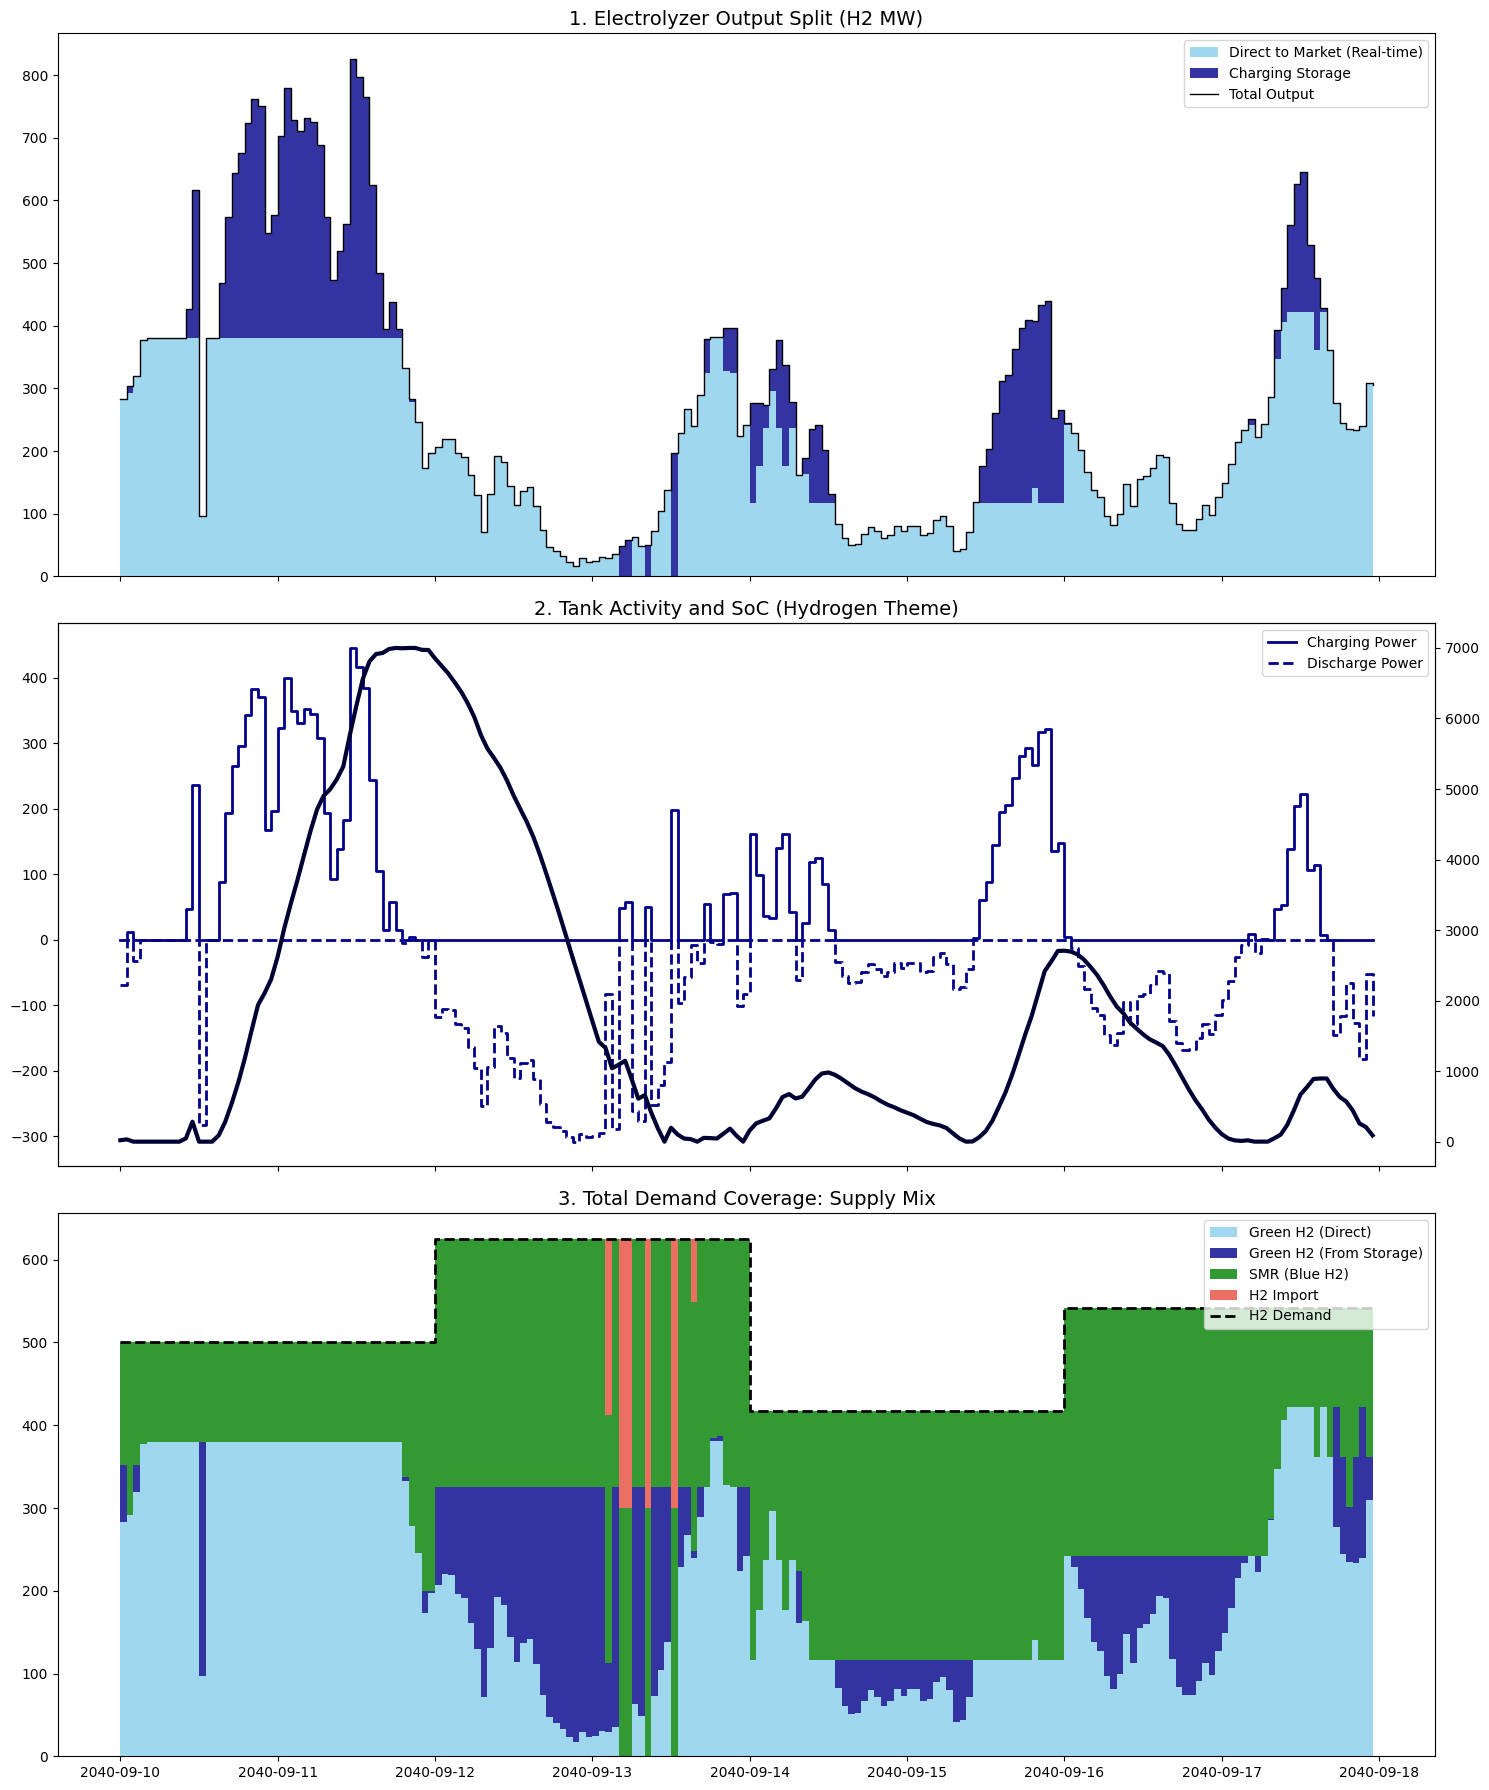

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Data Extraction ---
h2_load = n_h3.loads_t.p['H2_Demand']
smr_h2 = n_h3.links_t.p1['SMR_Plant'].abs()
h2_import_h2 = n_h3.generators_t.p['H2_Import']

# Electrolyzer and Storage Flows
elec_total_h2 = n_h3.links_t.p1['Electrolyzer_Decoupled'].abs()
storage_p = n_h3.stores_t.p['H2_Storage_Tank']
charge_p = -storage_p.clip(upper=0)
discharge_actual = storage_p.clip(lower=0)
soc = n_h3.stores_t.e['H2_Storage_Tank']

# --- 2. Logic for Demand Coverage (Graph 3) ---
true_direct_from_elec = (elec_total_h2 - charge_p).clip(lower=0)
true_from_storage = n_h3.links_t.p1['Via_Storage'].abs() + n_h3.links_t.p1['Direct_to_Market'].abs() - true_direct_from_elec
true_from_storage = true_from_storage.clip(lower=0)

# --- 3. Visualization ---
fig, axes = plt.subplots(3, 1, figsize=(15, 18), sharex=True)

# Subplot 1: Electrolyzer Split
labels_elec = ['Direct to Market (Real-time)', 'Charging Storage']
colors_elec = ['#87CEEB', '#00008B']
axes[0].stackplot(elec_total_h2.index, [true_direct_from_elec.values, charge_p.values], labels=labels_elec, colors=colors_elec, alpha=0.8, step='post')
axes[0].step(elec_total_h2.index, elec_total_h2.values, where='post', color='black', linewidth=1, label='Total Output')
axes[0].set_title('1. Electrolyzer Output Split (H2 MW)', fontsize=14)
axes[0].legend(loc='upper right')

# Subplot 2: Storage Dynamics
axes[1].step(charge_p.index, charge_p.values, where='post', color='#00008B', linewidth=2, label='Charging Power')
axes[1].step(discharge_actual.index, -discharge_actual.values, where='post', color='#00008B', linewidth=2, linestyle='--', label='Discharge Power')
ax1_twin = axes[1].twinx()
ax1_twin.plot(soc.index, soc.values, color='#000033', linewidth=3, label='SoC')
axes[1].set_title('2. Tank Activity and SoC (Hydrogen Theme)', fontsize=14)
axes[1].legend(loc='upper right')

# Subplot 3: Demand Coverage
labels_supply = ['Green H2 (Direct)', 'Green H2 (From Storage)', 'SMR (Blue H2)', 'H2 Import']
colors_supply = ['#87CEEB', '#00008B', 'green', '#e74c3c']
axes[2].stackplot(h2_load.index, [true_direct_from_elec.values, true_from_storage.values, smr_h2.values, h2_import_h2.values], labels=labels_supply, colors=colors_supply, alpha=0.8, step='post')
axes[2].step(h2_load.index, h2_load.values, where='post', color='black', linestyle='--', linewidth=2, label='H2 Demand')
axes[2].set_title('3. Total Demand Coverage: Supply Mix', fontsize=14)
axes[2].legend(loc='upper right')

plt.tight_layout()
plt.show()

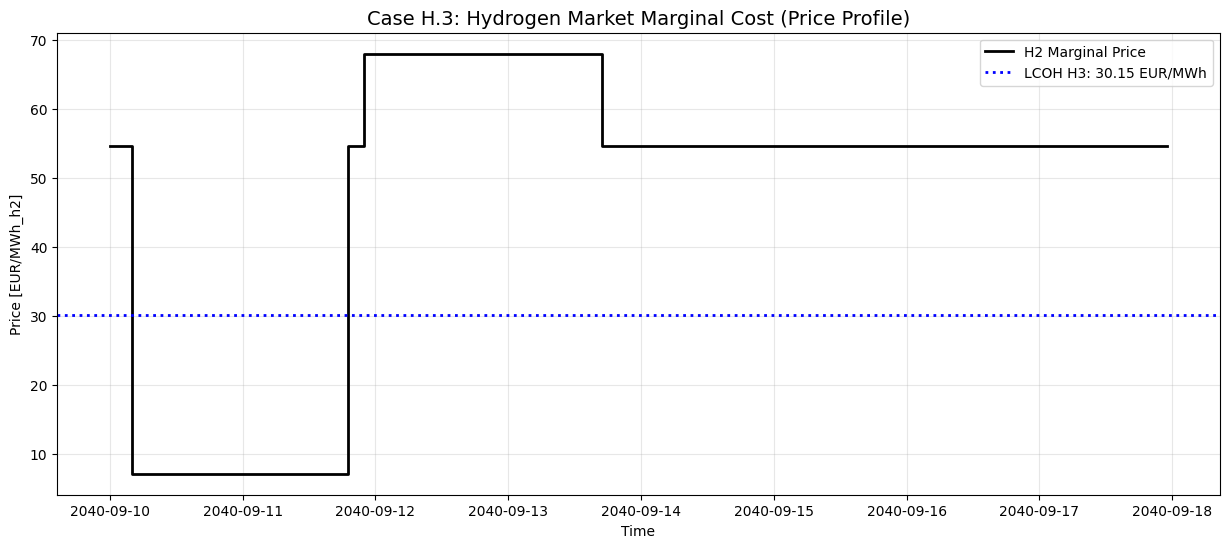

Average Marginal Cost in Case 3: 48.00 EUR/MWh


In [24]:
import matplotlib.pyplot as plt

# Extract the marginal price at the H2_Market bus for Case H.3
h2_price_h3 = n_h3.buses_t.marginal_price['H2_Market']
avg_price_h3 = h2_price_h3.mean()

total_cost_h3 = n_h3.objective
total_h3_demand = n_h3.loads_t.p['H2_Demand'].sum()
LCOH_h3_price = total_cost_h3 / total_h3_demand

plt.figure(figsize=(15, 6))
plt.step(h2_price_h3.index, h2_price_h3.values, where='post', color='black', linewidth=2, label='H2 Marginal Price')
plt.axhline(LCOH_h3_price, color='blue', linestyle=':', linewidth=2, label=f'LCOH H3: {LCOH_h3_price:.2f} EUR/MWh')

plt.title('Case H.3: Hydrogen Market Marginal Cost (Price Profile)', fontsize=14)
plt.ylabel('Price [EUR/MWh_h2]')
plt.xlabel('Time')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Average Marginal Cost in Case 3: {avg_price_h3:.2f} EUR/MWh")

In [25]:
import plotly.graph_objects as go

# --- 1. Calculate required energy flows (MWh) from n_h3 ---
wind_to_elec = n_h3.links_t.p0['Electrolyzer_Decoupled'].sum()
elec_to_storage = n_h3.links_t.p1['Electrolyzer_Decoupled'].abs().sum()
ch4_to_smr = n_h3.links_t.p0['SMR_Plant'].sum()
smr_to_h2 = n_h3.links_t.p1['SMR_Plant'].abs().sum()
import_to_h2 = n_h3.generators_t.p['H2_Import'].sum()

# Storage activity
storage_charge = -n_h3.stores_t.p['H2_Storage_Tank'].clip(upper=0).sum()
storage_discharge = n_h3.stores_t.p['H2_Storage_Tank'].clip(lower=0).sum()

# Interface flows
direct_to_market = n_h3.links_t.p1['Direct_to_Market'].abs().sum()
via_storage_to_market = n_h3.links_t.p1['Via_Storage'].abs().sum()

# Losses
elec_loss = wind_to_elec - elec_to_storage
smr_loss = ch4_to_smr - smr_to_h2

# --- 2. Define Nodes and Links ---
labels = ["H2 Storage Bus", "H2 Market", "Storage Tank", "Wind Farm", "CH4 Grid", "Electrolyzer", "SMR Plant", "H2 Import", "Conversion Losses"]
colors = ["#9b59b6", "#e67e22", "#00008B", "skyblue", "orange", "#3498db", "green", "#e74c3c", "#95a5a6"]

fig = go.Figure(data=[go.Sankey(
    valueformat = ".0f",
    valuesuffix = " MWh",
    node = dict(pad = 15, thickness = 20, line = dict(color = "black", width = 0.5), label = labels, color = colors),
    link = dict(
      source = [3, 4, 5, 6, 7, 0, 0, 0, 2, 5, 6],
      target = [5, 6, 0, 1, 1, 1, 1, 2, 0, 8, 8],
      value = [wind_to_elec, ch4_to_smr, elec_to_storage, smr_to_h2, import_to_h2, direct_to_market, via_storage_to_market, storage_charge, storage_discharge, elec_loss, smr_loss]
    )
)])

fig.update_layout(title_text="Case H.3: Full Hydrogen System Energy Flow - [MWh]")
fig.show()

In [26]:
import pandas as pd

# Using the refined variables calculated in the previous plotting cell
total_demand = n_h3.loads_t.p['H2_Demand'].sum()
total_smr = n_h3.links_t.p1['SMR_Plant'].abs().sum()
total_import = n_h3.generators_t.p['H2_Import'].sum()

# These variables 'true_direct_from_elec' and 'true_from_storage' were defined in cell R8xcB2K7HG0z
sum_direct_green = true_direct_from_elec.sum()
sum_storage_green = true_from_storage.sum()

# Data from Case H.3 variables calculated in previous cells
h3_summary_data = {
    'Metric': [
        'Total H2 Demand',
        'Green H2 (Direct)',
        'Green H2 (From Storage)',
        'Blue H2 (SMR)',
        'H2 Imports'
    ],
    'Value': [
        f"{total_demand:,.0f} MWh",
        f"{(sum_direct_green/total_demand)*100:.1f}%",
        f"{(sum_storage_green/total_demand)*100:.1f}%",
        f"{(total_smr/total_demand)*100:.1f}%",
        f"{(total_import/total_demand)*100:.1f}%"
    ]
}

df_h3_simple = pd.DataFrame(h3_summary_data)

# Display cleaned table without index
display(df_h3_simple.style.hide(axis='index'))

Metric,Value
Total H2 Demand,"100,000 MWh"
Green H2 (Direct),39.5%
Green H2 (From Storage),12.5%
Blue H2 (SMR),46.4%
H2 Imports,1.6%


In [27]:
# wind utilisation
total_wind_potential_mwh = (input_profiles.loc[period_snapshots, 'df_wind'] * wind_p_nom).sum()

# 2. Calculate Wind Used for each case (p0 of the electrolyzer)
wind_used_h1 = n_h1.links_t.p0['Electrolyzer_Decoupled'].sum()
wind_used_h2 = n_h2.links_t.p0['Electrolyzer_Decoupled'].sum()
wind_used_h3 = n_h3.links_t.p0['Electrolyzer_Decoupled'].sum()

# 3. Create Comparison Table
comparison_data = {
    'Case': ['H.1 (Basic)', 'H.2 (with SMR)', 'H.3 (with Storage)'],
    'Wind Potential [MWh]': [f"{total_wind_potential_mwh:,.1f}"] * 3,
    'Wind Used [MWh]': [
        f"{wind_used_h1:,.1f}",
        f"{wind_used_h2:,.1f}",
        f"{wind_used_h3:,.1f}"
    ],
    'Utilization Ratio [%]': [
        f"{(wind_used_h1/total_wind_potential_mwh)*100:.1f}%",
        f"{(wind_used_h2/total_wind_potential_mwh)*100:.1f}%",
        f"{(wind_used_h3/total_wind_potential_mwh)*100:.1f}%"
    ]
}

df_comparison = pd.DataFrame(comparison_data)
display(df_comparison.style.hide(axis='index'))

Case,Wind Potential [MWh],Wind Used [MWh],Utilization Ratio [%]
H.1 (Basic),"77,044.1","69,962.6",90.8%
H.2 (with SMR),"77,044.1","62,008.3",80.5%
H.3 (with Storage),"77,044.1","74,347.1",96.5%


**Summary: Case H.3 - Hydrogen System with Storage**

This configuration represents the most advanced setup, adding a **Hydrogen Storage Tank** to the mix:

*   **Increased Flexibility**: Storage allows the system to decouple real-time wind production from hydrogen demand. Surplus green hydrogen is stored during windy periods and discharged when wind is scarce.
*   **Reduced Peak Imports**: By using stored green hydrogen, the system drastically reduces its reliance on expensive H2 imports (dropping from ~13% in Case H.2 to only ~1.6% here).
*   **Operational Optimization**: The storage tank acts as a buffer that smooths out the 'price spikes,' allowing the electrolyzer to run more frequently at low-cost hours.
*   **Lower Overall Costs**: This added flexibility results in the lowest Levelized Cost of Hydrogen (LCOH) among all three cases, as cheaper green energy is maximized.

# Case H.4: Interlinked Markets - Hydrogen and Gas

In [28]:
# Case H.4 : Further Development (Interlinked H2 and CH4)

# Local overrides for Case H.4 only:
p_wind_h4 = 3950
p_SMR_h4 = 500
p_syn_methene_nom = 750
divide_CH4_cons = 2.0

# 1. Initialize Network
n_h4 = pypsa.Network()
n_h4.set_snapshots(period_snapshots)

# 2. Define Carriers explicitly
n_h4.add("Carrier", "AC")
n_h4.add("Carrier", "H2")
n_h4.add("Carrier", "CH4")

# 3. Add Buses
n_h4.add("Bus", "AC_Bus", carrier="AC")
n_h4.add("Bus", "H2_Bus", carrier="H2")
n_h4.add("Bus", "CH4_Bus", carrier="CH4")

# 4. H2 Supply (Wind -> Electrolyzer -> H2_Bus)
n_h4.add("Generator", "Wind",
         bus="AC_Bus",
         p_nom=p_wind_h4,
         p_max_pu=input_profiles.loc[period_snapshots, 'df_wind'],
         marginal_cost=5.0,
         carrier="wind")

n_h4.add("Link", "Electrolyzer_Decoupled",
         bus0="AC_Bus",
         bus1="H2_Bus",
         p_nom=p_wind_h4,
         efficiency=0.7,
         carrier="electrolysis")

# 5. H2 Storage (Reverted: No power limits)
h2_storage_energy_h4 = 10000

n_h4.add("Store", "H2_Storage",
         bus="H2_Bus",
         e_nom=h2_storage_energy_h4,
         e_cyclic=True,
         carrier="H2")

# 6. Demands
n_h4.add("Load", "H2_Demand",
         bus="H2_Bus",
         p_set=h2_demand_hourly)

n_h4.add("Load", "CH4_Demand",
         bus="CH4_Bus",
         p_set=ch4_demand_hourly/divide_CH4_cons)

# 7. H2 and CH4 Imports
n_h4.add("Generator", "H2_Import",
         bus="H2_Bus",
         p_nom_extendable=True,
         marginal_cost=68,
         carrier="H2")

n_h4.add("Generator", "CH4_Import",
         bus="CH4_Bus",
         p_nom_extendable=True,
         marginal_cost=40,
         carrier="CH4")

# 8. Conversion Links (SMR and Sabatier)
n_h4.add("Link", "SMR_Plant",
         bus0="CH4_Bus",
         bus1="H2_Bus",
         p_nom=p_SMR_h4,
         p_min_pu=0.4,
         ramp_limit_up=0.2,
         ramp_limit_down=0.2,
         efficiency=0.75,
         marginal_cost=1,
         carrier="SMR")

n_h4.add("Link", "Sabatier_Plant",
         bus0="H2_Bus",
         bus1="CH4_Bus",
         ramp_limit_up=0.2,
         ramp_limit_down=0.2,
         efficiency=0.83,
         p_nom=p_syn_methene_nom,
         carrier="Sabatier")

# 9. Sanitize and Optimize
n_h4.sanitize()
n_h4.optimize(solver_name='highs', include_objective_constant=False)

('ok', 'optimal')

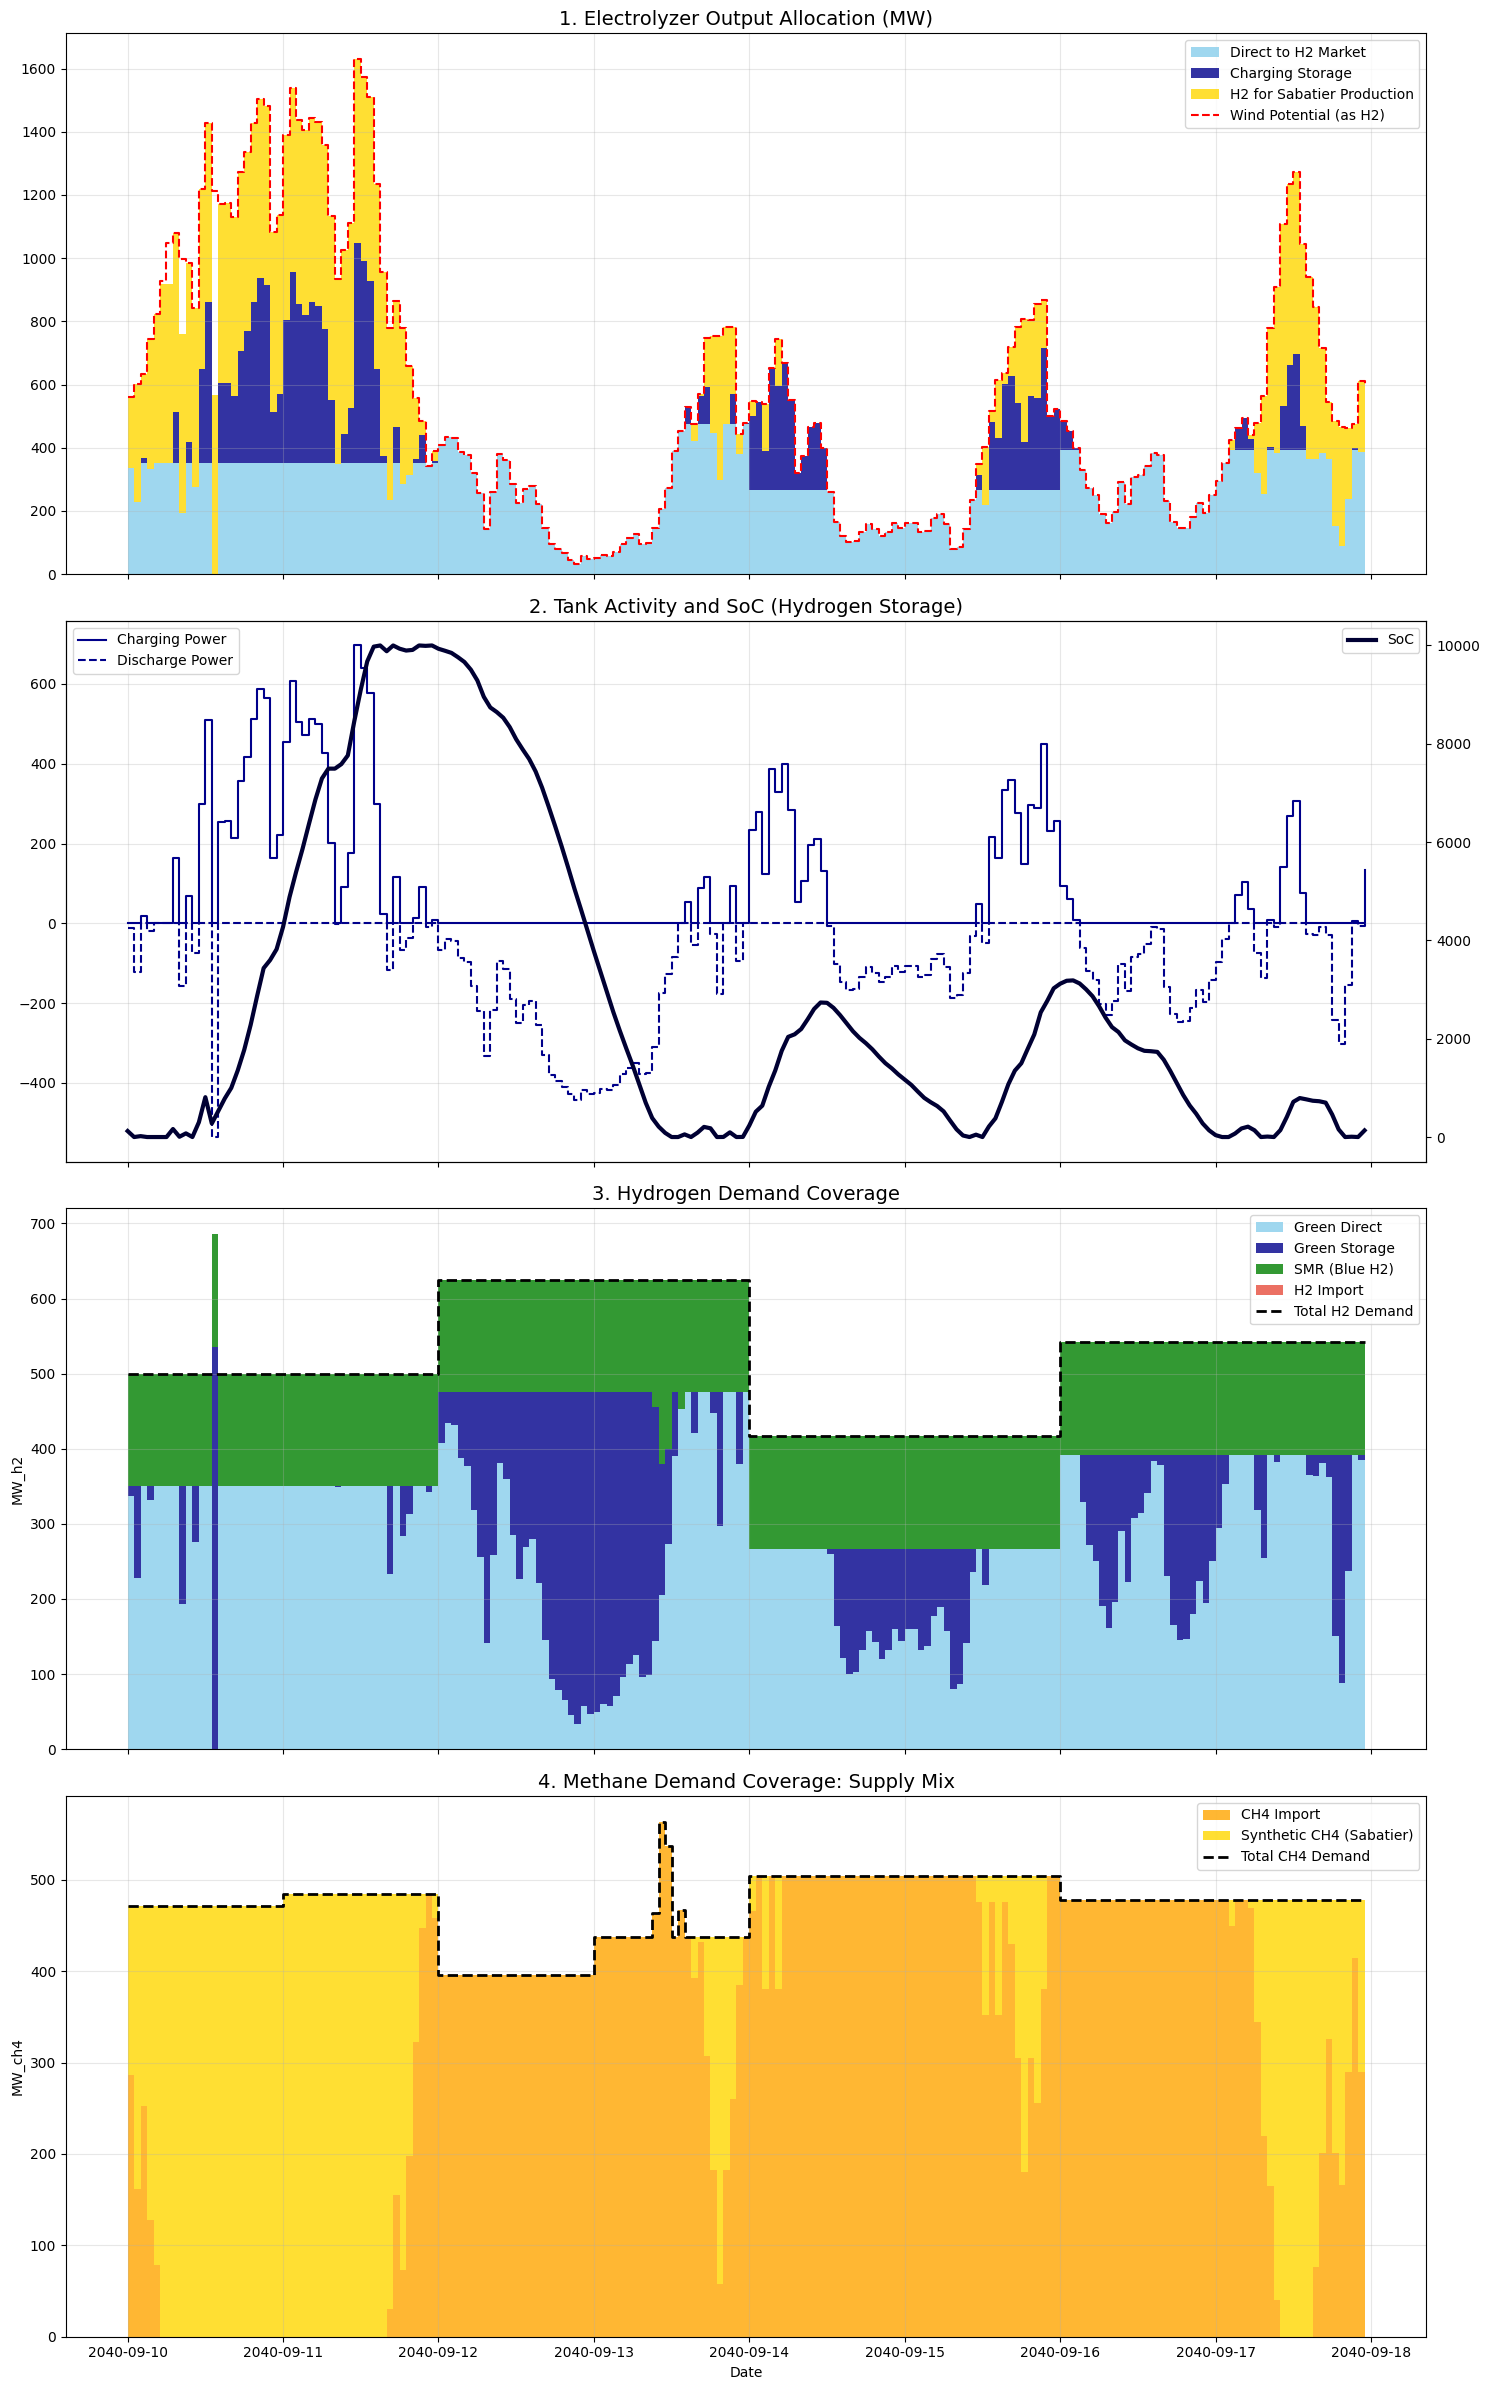

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Data Extraction ---
h2_load_h4 = n_h4.loads_t.p['H2_Demand']
smr_h2_h4 = n_h4.links_t.p1['SMR_Plant'].abs()
h2_import_h2_h4 = n_h4.generators_t.p['H2_Import']

# CH4 Data Extraction
ch4_load_h4 = n_h4.loads_t.p['CH4_Demand']
ch4_import_h4 = n_h4.generators_t.p['CH4_Import']
smr_ch4_consumption = n_h4.links_t.p0['SMR_Plant'].abs()
total_ch4_demand_h4 = ch4_load_h4 + smr_ch4_consumption

# Electrolyzer and Storage Flows
elec_total_h2_h4 = n_h4.links_t.p1['Electrolyzer_Decoupled'].abs()
storage_p_h4 = n_h4.stores_t.p['H2_Storage']
charge_p_h4 = -storage_p_h4.clip(upper=0)
discharge_actual_h4 = storage_p_h4.clip(lower=0)
soc_h4 = n_h4.stores_t.e['H2_Storage']

# Sabatier CH4 output and H2 input
sabatier_ch4_output = n_h4.links_t.p1['Sabatier_Plant'].abs()
sabatier_h2_input = n_h4.links_t.p0['Sabatier_Plant'].abs()

# Wind Potential (scaled by efficiency)
wind_potential_h2_h4 = (n_h4.generators_t.p_max_pu['Wind'] * n_h4.generators.at['Wind', 'p_nom']) * n_h4.links.at['Electrolyzer_Decoupled', 'efficiency']

# Logic for Demand Coverage
# Direct green is what goes to bus minus what goes to storage or Sabatier
true_direct_from_elec_h4 = (elec_total_h2_h4 - charge_p_h4 - sabatier_h2_input).clip(lower=0)
true_from_storage_h4 = discharge_actual_h4

# --- 2. Visualization ---
fig, axes = plt.subplots(4, 1, figsize=(15, 24), sharex=True)

# Subplot 1: Electrolyzer Split
labels_elec = ['Direct to H2 Market', 'Charging Storage', 'H2 for Sabatier Production']
colors_elec_v2 = ['#87CEEB', '#00008B', 'gold']
axes[0].stackplot(elec_total_h2_h4.index,
                  [true_direct_from_elec_h4.values, charge_p_h4.values, sabatier_h2_input.values],
                  labels=labels_elec, colors=colors_elec_v2, alpha=0.8, step='post')
axes[0].step(wind_potential_h2_h4.index, wind_potential_h2_h4.values, where='post', color='red', linestyle='--', linewidth=1.5, label='Wind Potential (as H2)')
axes[0].set_title('1. Electrolyzer Output Allocation (MW)', fontsize=14)
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# Subplot 2: Storage Dynamics
axes[1].step(charge_p_h4.index, charge_p_h4.values, where='post', color='#00008B', label='Charging Power')
axes[1].step(discharge_actual_h4.index, -discharge_actual_h4.values, where='post', color='#00008B', linestyle='--', label='Discharge Power')
ax2_twin = axes[1].twinx()
ax2_twin.plot(soc_h4.index, soc_h4.values, color='#000033', linewidth=3, label='SoC')
axes[1].set_title('2. Tank Activity and SoC (Hydrogen Storage)', fontsize=14)
axes[1].legend(loc='upper left')
ax2_twin.legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

# Subplot 3: H2 Demand Coverage
axes[2].stackplot(h2_load_h4.index,
                  [true_direct_from_elec_h4.values, true_from_storage_h4.values, smr_h2_h4.values, h2_import_h2_h4.values],
                  labels=['Green Direct', 'Green Storage', 'SMR (Blue H2)', 'H2 Import'],
                  colors=['#87CEEB', '#00008B', 'green', '#e74c3c'], alpha=0.8, step='post')
axes[2].step(h2_load_h4.index, h2_load_h4.values, where='post', color='black', linestyle='--', linewidth=2, label='Total H2 Demand')
axes[2].set_title('3. Hydrogen Demand Coverage', fontsize=14)
axes[2].set_ylabel('MW_h2')
axes[2].legend(loc='upper right')
axes[2].grid(True, alpha=0.3)

# Subplot 4: CH4 Demand Coverage
labels_ch4_supply = ['CH4 Import', 'Synthetic CH4 (Sabatier)']
colors_ch4_supply = ['orange', 'gold']
axes[3].stackplot(ch4_load_h4.index,
                  [ch4_import_h4.values, sabatier_ch4_output.values],
                  labels=labels_ch4_supply, colors=colors_ch4_supply, alpha=0.8, step='post')
axes[3].step(ch4_load_h4.index, total_ch4_demand_h4.values, where='post', color='black', linestyle='--', linewidth=2, label='Total CH4 Demand')
axes[3].set_title('4. Methane Demand Coverage: Supply Mix', fontsize=14)
axes[3].set_ylabel('MW_ch4')
axes[3].set_xlabel('Date')
axes[3].legend(loc='upper right')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

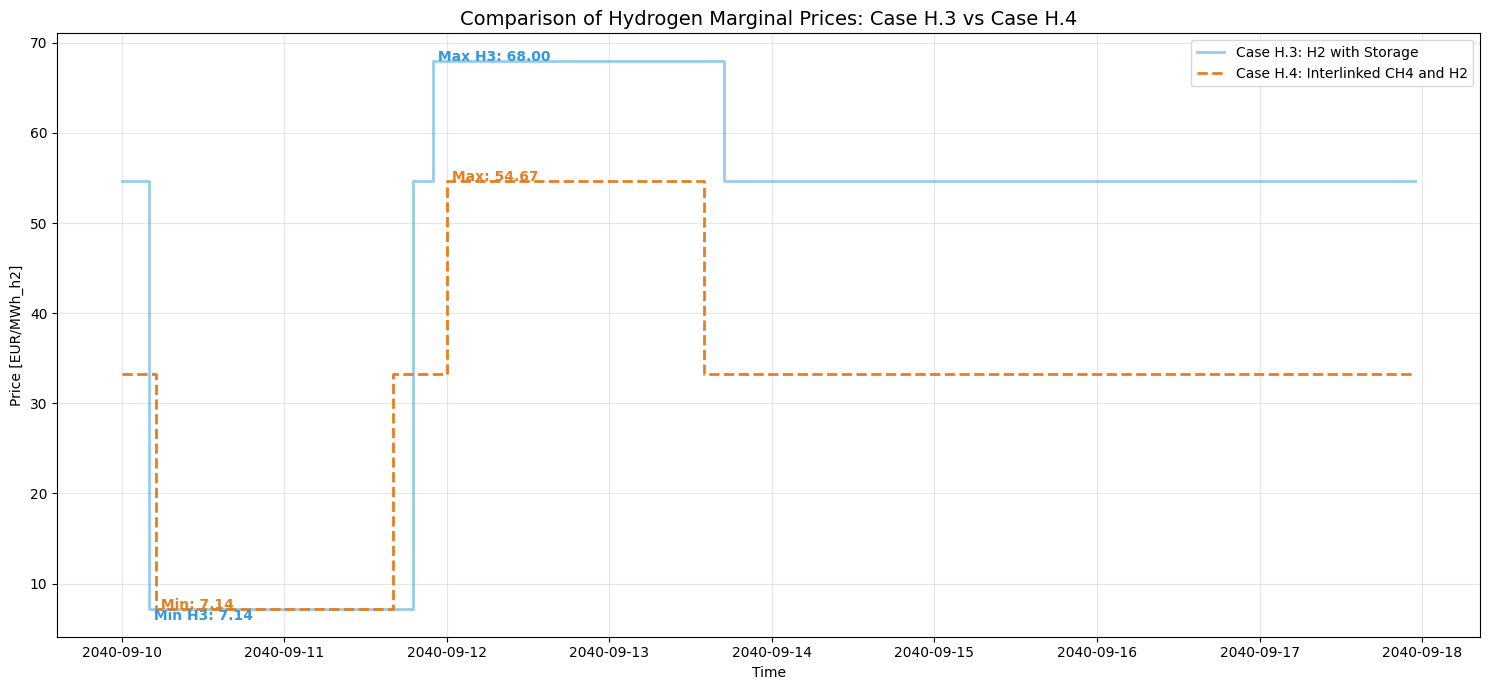

In [30]:
import matplotlib.pyplot as plt

# 1. Extract Marginal Prices
h2_price_h3 = n_h3.buses_t.marginal_price['H2_Market']
h2_price_h4 = n_h4.buses_t.marginal_price['H2_Bus']

# 2. Plotting comparison
plt.figure(figsize=(15, 7))

plt.step(h2_price_h3.index, h2_price_h3.values, where='post',
         color='#3498db', linewidth=2, label='Case H.3: H2 with Storage', alpha=0.5)

plt.step(h2_price_h4.index, h2_price_h4.values, where='post',
         color='#e67e22', linewidth=2, label='Case H.4: Interlinked CH4 and H2', linestyle='--')

# Annotate Max/Min for Case H.4
plt.text(h2_price_h4.idxmax(), h2_price_h4.max(), f" Max: {h2_price_h4.max():.2f}", color='#e67e22', fontweight='bold')
plt.text(h2_price_h4.idxmin(), h2_price_h4.min(), f" Min: {h2_price_h4.min():.2f}", color='#e67e22', fontweight='bold')

# Annotate Max/Min for Case H.3
plt.text(h2_price_h3.idxmax(), h2_price_h3.max(), f" Max H3: {h2_price_h3.max():.2f}", color='#3498db', fontweight='bold')
plt.text(h2_price_h3.idxmin(), h2_price_h3.min(), f" Min H3: {h2_price_h3.min():.2f}", color='#3498db', fontweight='bold', verticalalignment='top')

plt.title('Comparison of Hydrogen Marginal Prices: Case H.3 vs Case H.4', fontsize=14)
plt.ylabel('Price [EUR/MWh_h2]')
plt.xlabel('Time')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


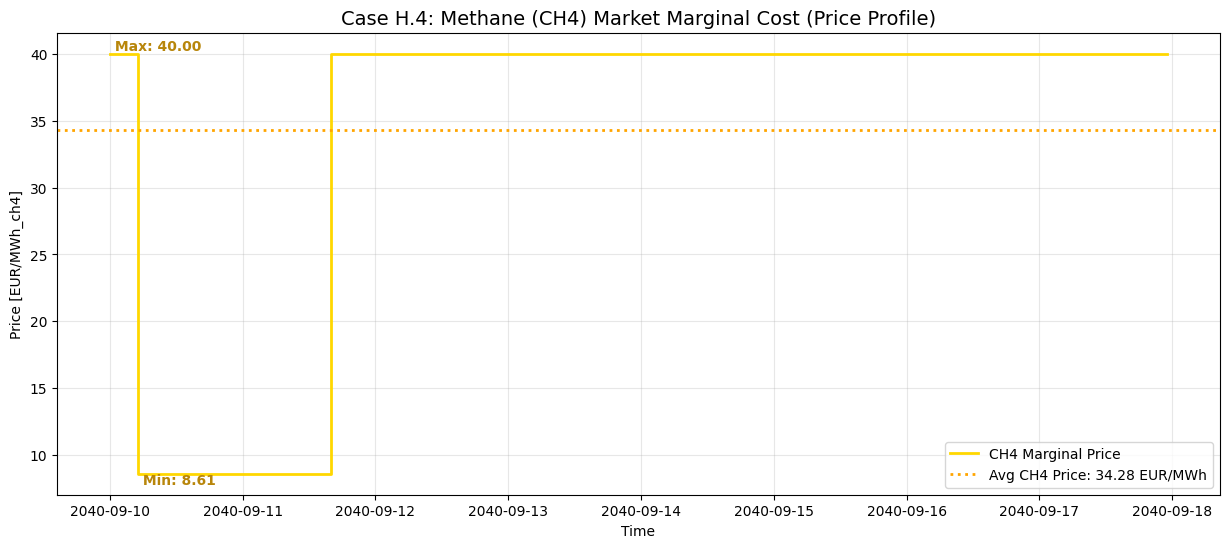

Average Marginal Cost of Methane (CH4): 34.28 EUR/MWh
CH4 Price Range: Min 8.61 / Max 40.00 EUR/MWh


In [31]:
import matplotlib.pyplot as plt

# Extract the marginal price at the CH4_Bus bus for Case H.4
ch4_price_h4 = n_h4.buses_t.marginal_price['CH4_Bus']
avg_ch4_price = ch4_price_h4.mean()
max_ch4 = ch4_price_h4.max()
min_ch4 = ch4_price_h4.min()

plt.figure(figsize=(15, 6))
plt.step(ch4_price_h4.index, ch4_price_h4.values, where='post', color='gold', linewidth=2, label='CH4 Marginal Price')
plt.axhline(avg_ch4_price, color='orange', linestyle=':', linewidth=2, label=f'Avg CH4 Price: {avg_ch4_price:.2f} EUR/MWh')

# Annotate Max/Min
plt.text(ch4_price_h4.idxmax(), max_ch4, f" Max: {max_ch4:.2f}", color='darkgoldenrod', fontweight='bold', verticalalignment='bottom')
plt.text(ch4_price_h4.idxmin(), min_ch4, f" Min: {min_ch4:.2f}", color='darkgoldenrod', fontweight='bold', verticalalignment='top')

plt.title('Case H.4: Methane (CH4) Market Marginal Cost (Price Profile)', fontsize=14)
plt.ylabel('Price [EUR/MWh_ch4]')
plt.xlabel('Time')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Average Marginal Cost of Methane (CH4): {avg_ch4_price:.2f} EUR/MWh")
print(f"CH4 Price Range: Min {min_ch4:.2f} / Max {max_ch4:.2f} EUR/MWh")

**Detailed Calculation of Price Extremes in Case H.4**

In Case H.4, the Hydrogen (H2) and Methane (CH4) markets are interlinked. The marginal price at the **H2_Bus** is set by the most expensive technology currently required to meet the next unit of demand.

**1. Calculation of the Minimum Price (The Green Floor)**
When there is surplus wind energy, the price of hydrogen is determined by the cost of converting electricity into gas.
*   **Formula**: `Wind Marginal Cost` / `Electrolyzer Efficiency`
*   **Values**: $5.0 \text{ EUR/MWh} / 0.70$
*   **Result**: **7.14 EUR/MWh**
*   *Mechanism*: As long as the wind farm has spare capacity and the electrolyzer is not bottlenecked, this low price prevails.

**2. Calculation of the Maximum Price (The Blue Ceiling)**
When wind is insufficient, the system must either import hydrogen or produce it from methane via the SMR plant. In this case, the SMR plant sets the 'ceiling' for the price.
*   **Formula**: (`CH4 Price` / `SMR Efficiency`) + `SMR Variable Cost`
*   **Values**: ($40.0 \text{ EUR/MWh} / 0.75$) + $1.0 \text{ EUR/MWh}$
*   **Calculation**: $53.33 + 1.0 = 54.33 \text{ EUR/MWh}$
*   **Result**: **~54.33 EUR/MWh**
*   *Mechanism*: This is the 'opportunity cost' of methane. If the H2 price rose any higher, it would be cheaper to simply import more methane and convert it. Thus, the gas market effectively caps the hydrogen price in this scenario.'

**3. Calculation of the 33.20 EUR/MWh Price (Methane Coupling)**

In Case H.4, the Hydrogen price is frequently pegged at **33.20 EUR/MWh**. This is defined by the **Methane Market Price** and the **Sabatier Plant efficiency**.

*   **Methane Market Price**: 40.0 EUR/MWh (Price of CH4 imports).
*   **Sabatier Efficiency**: 0.83 (83% conversion efficiency from H2 to CH4).

**The Calculation:**
$$\text{H2 Price} = \text{CH4 Price} \times \text{Sabatier Efficiency}$$
$$\text{H2 Price} = 40.0 \times 0.83 = 33.20 \text{ EUR/MWh}$$

**Economic Meaning:**
This value represents the **opportunity value** of Hydrogen. At any price below 33.20, it is more valuable for the system to turn the Hydrogen into Methane (to save on gas imports) than it is to use it for anything else. This creates a 'price floor' at 33.20 whenever the Sabatier plant is the marginal consumer.

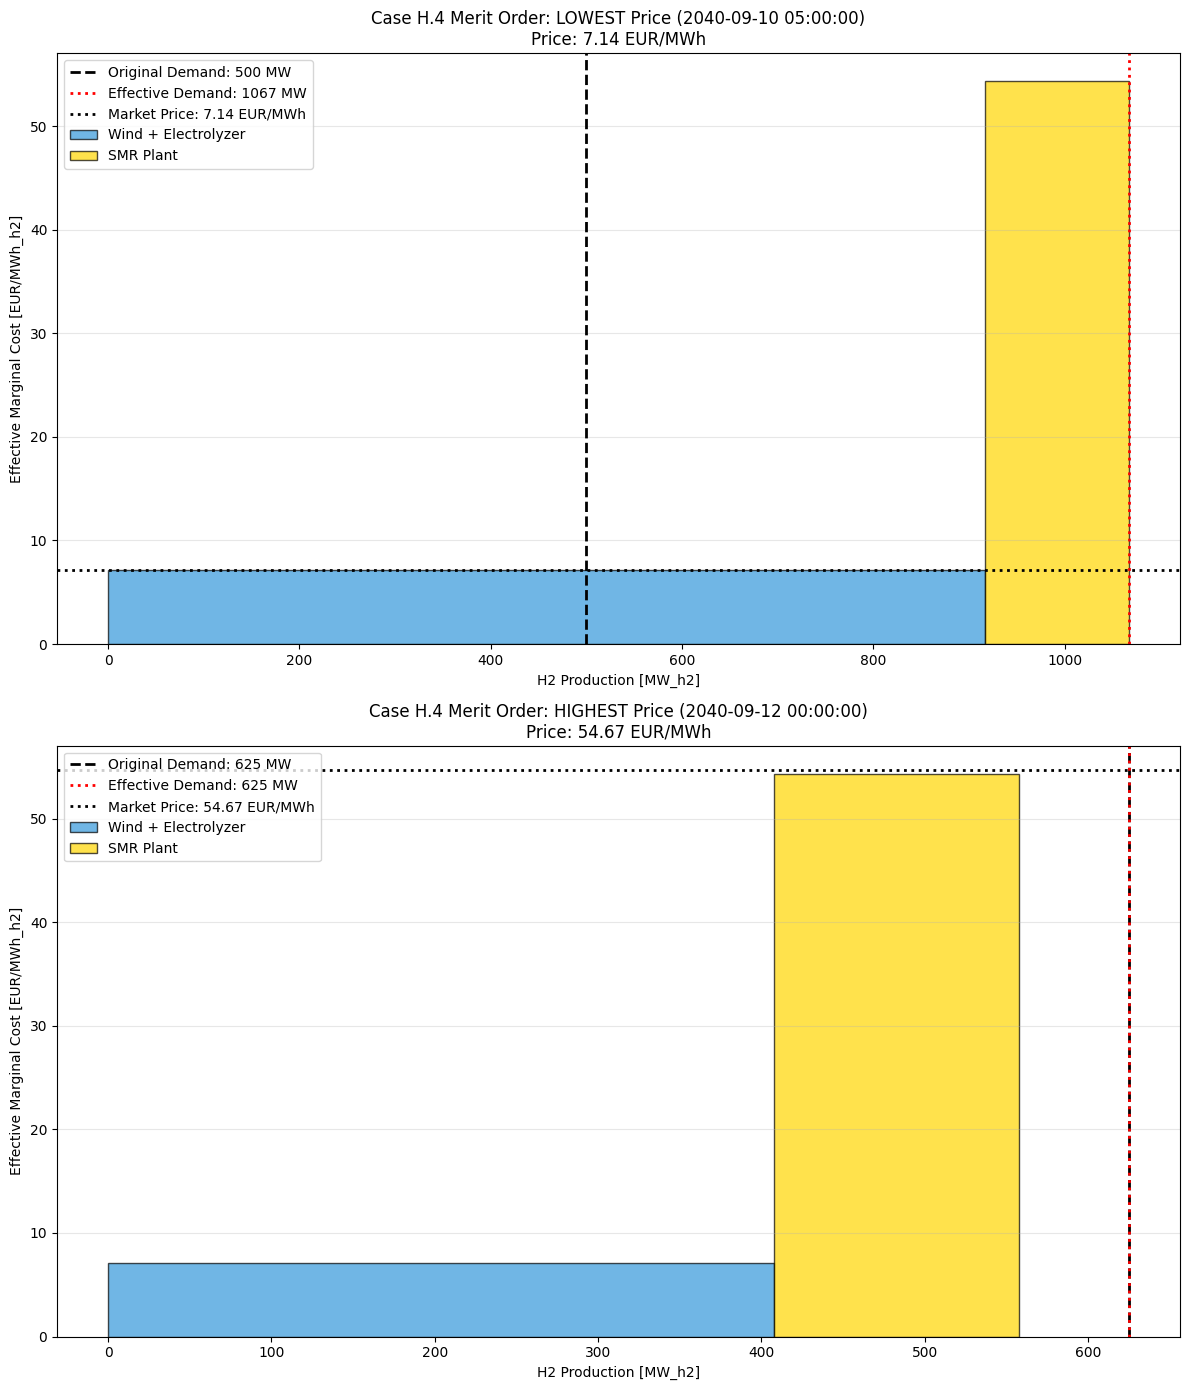

In [32]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def plot_h2_merit_order_snapshot(network, snapshot, ax, title):
    # Calculate effective marginal costs for H2 supply components
    wind_eff_cost = network.generators.at['Wind', 'marginal_cost'] / network.links.at['Electrolyzer_Decoupled', 'efficiency']
    import_cost = network.generators.at['H2_Import', 'marginal_cost']
    smr_eff_cost = (network.generators.at['CH4_Import', 'marginal_cost'] / network.links.at['SMR_Plant', 'efficiency']) + network.links.at['SMR_Plant', 'marginal_cost']

    data = [
        {'name': 'Wind + Electrolyzer', 'cost': wind_eff_cost, 'dispatch': abs(network.links_t.p1.loc[snapshot, 'Electrolyzer_Decoupled'])},
        {'name': 'SMR Plant', 'cost': smr_eff_cost, 'dispatch': abs(network.links_t.p1.loc[snapshot, 'SMR_Plant'])},
        {'name': 'H2 Import', 'cost': import_cost, 'dispatch': abs(network.generators_t.p.loc[snapshot, 'H2_Import'])}
    ]

    df_mo = pd.DataFrame(data)
    df_mo = df_mo[df_mo['dispatch'] > 0.01].sort_values(by='cost')

    if df_mo.empty:
        ax.text(0.5, 0.5, 'No H2 production at this snapshot.', horizontalalignment='center', verticalalignment='center', fontsize=12)
        ax.set_title(title)
        return

    df_mo['cum_dispatch'] = df_mo['dispatch'].cumsum()
    df_mo['prev_cum'] = df_mo['cum_dispatch'].shift(1, fill_value=0)

    colors = ['#3498db', 'gold', '#e74c3c']
    for i, row in df_mo.iterrows():
        ax.bar(row['prev_cum'], row['cost'], width=row['dispatch'],
               align='edge', label=row['name'], color=colors[i % len(colors)],
               alpha=0.7, edgecolor='black')

    # --- Demand lines ---
    # Original Demand (External Load)
    orig_load = network.loads_t.p.loc[snapshot, 'H2_Demand']
    ax.axvline(orig_load, color='black', linestyle='--', linewidth=2, label=f'Original Demand: {orig_load:.0f} MW')

    # Effective Demand (Original + Sabatier Input)
    sabatier_input = abs(network.links_t.p0.loc[snapshot, 'Sabatier_Plant'])
    eff_load = orig_load + sabatier_input
    ax.axvline(eff_load, color='red', linestyle=':', linewidth=2, label=f'Effective Demand: {eff_load:.0f} MW')

    # Price line
    sys_price = network.buses_t.marginal_price.at[snapshot, 'H2_Bus']
    ax.axhline(sys_price, color='black', linestyle=':', linewidth=2, label=f'Market Price: {sys_price:.2f} EUR/MWh')

    ax.set_title(title)
    ax.set_xlabel('H2 Production [MW_h2]')
    ax.set_ylabel('Effective Marginal Cost [EUR/MWh_h2]')
    ax.legend(loc='upper left')
    ax.grid(axis='y', alpha=0.3)

# --- Identify Snapshots ---
h2_prices_h4 = n_h4.buses_t.marginal_price['H2_Bus']
high_price_time = h2_prices_h4.idxmax()
low_price_time = h2_prices_h4.idxmin()

# --- Plotting Comparison ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 14))

plot_h2_merit_order_snapshot(n_h4, low_price_time, ax1,
                             f"Case H.4 Merit Order: LOWEST Price ({low_price_time})\nPrice: {h2_prices_h4.min():.2f} EUR/MWh")

plot_h2_merit_order_snapshot(n_h4, high_price_time, ax2,
                             f"Case H.4 Merit Order: HIGHEST Price ({high_price_time})\nPrice: {h2_prices_h4.max():.2f} EUR/MWh")

plt.tight_layout()
plt.show()

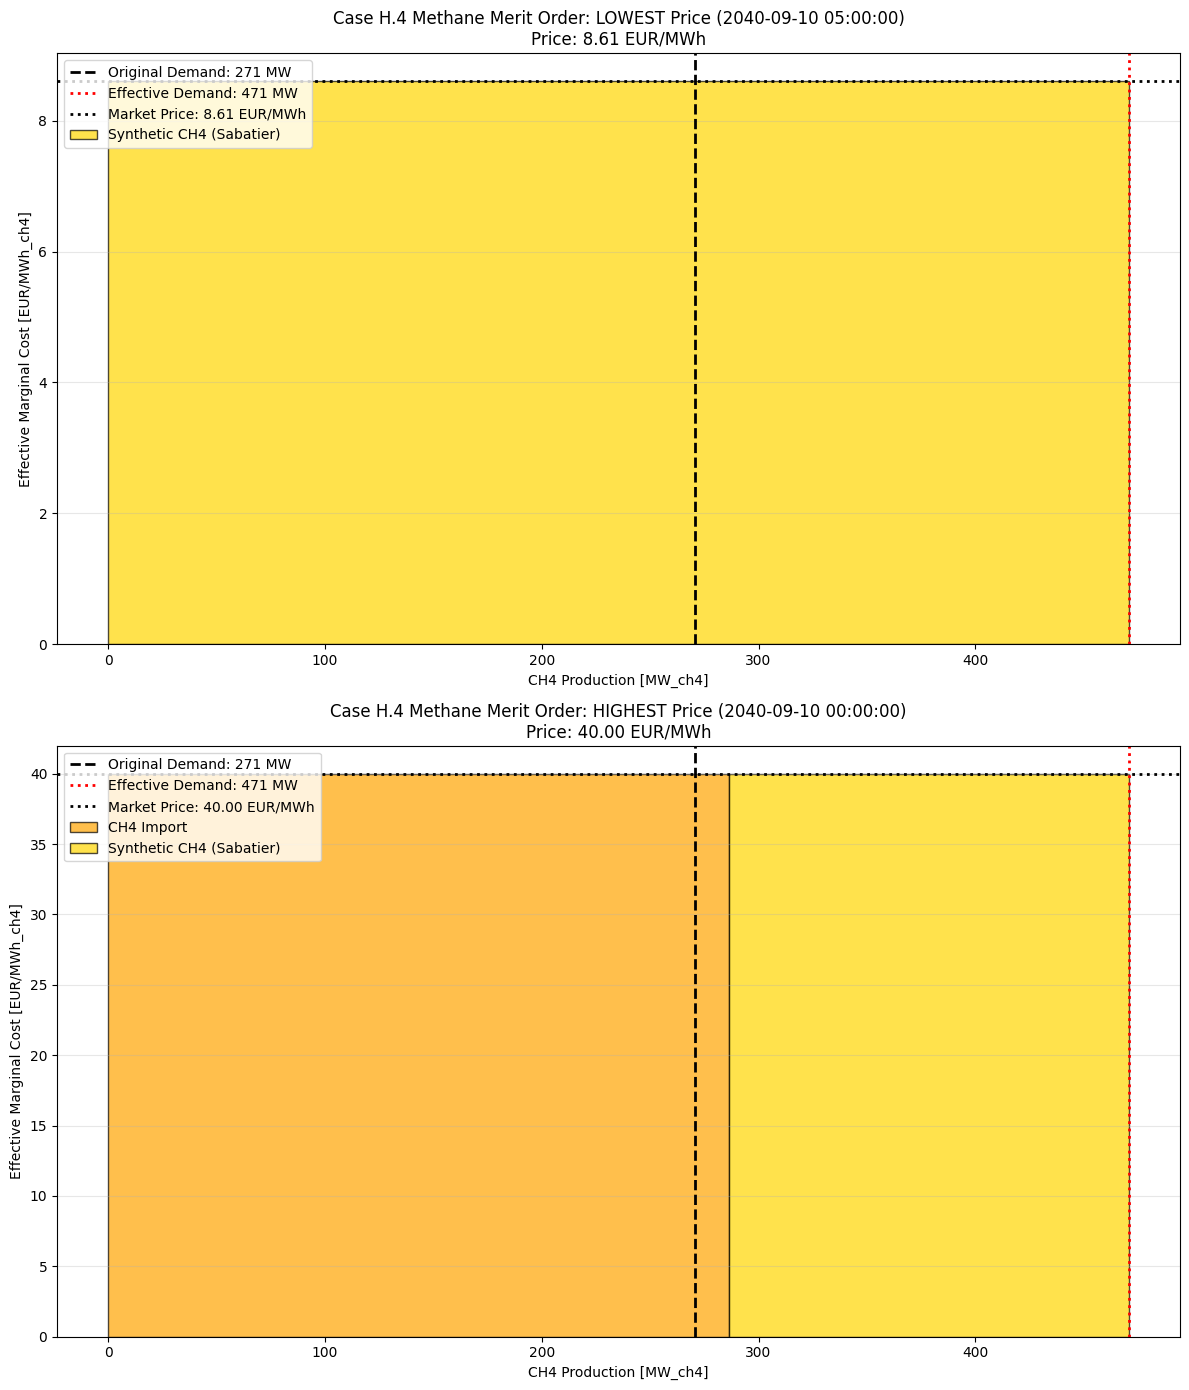

In [33]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def plot_ch4_merit_order_snapshot(network, snapshot, ax, title):
    # Calculate effective marginal costs for CH4 supply components
    import_cost = network.generators.at['CH4_Import', 'marginal_cost']
    # Sabatier effective cost depends on H2 price input
    h2_price = network.buses_t.marginal_price.at[snapshot, 'H2_Bus']
    sabatier_eff_cost = h2_price / network.links.at['Sabatier_Plant', 'efficiency']

    data = [
        {'name': 'CH4 Import', 'cost': import_cost, 'dispatch': abs(network.generators_t.p.loc[snapshot, 'CH4_Import'])},
        {'name': 'Synthetic CH4 (Sabatier)', 'cost': sabatier_eff_cost, 'dispatch': abs(network.links_t.p1.loc[snapshot, 'Sabatier_Plant'])}
    ]

    df_mo = pd.DataFrame(data)
    df_mo = df_mo[df_mo['dispatch'] > 0.01].sort_values(by='cost')

    if df_mo.empty:
        ax.text(0.5, 0.5, 'No CH4 production at this snapshot.', horizontalalignment='center', verticalalignment='center', fontsize=12)
        ax.set_title(title)
        return

    df_mo['cum_dispatch'] = df_mo['dispatch'].cumsum()
    df_mo['prev_cum'] = df_mo['cum_dispatch'].shift(1, fill_value=0)

    colors = ['orange', 'gold']
    for i, row in df_mo.iterrows():
        ax.bar(row['prev_cum'], row['cost'], width=row['dispatch'],
               align='edge', label=row['name'], color=colors[i % len(colors)],
               alpha=0.7, edgecolor='black')

    # --- Demand lines ---
    # Original Demand (External Load)
    orig_load = network.loads_t.p.loc[snapshot, 'CH4_Demand']
    ax.axvline(orig_load, color='black', linestyle='--', linewidth=2, label=f'Original Demand: {orig_load:.0f} MW')

    # Effective Demand (Original + SMR Input)
    smr_input = abs(network.links_t.p0.loc[snapshot, 'SMR_Plant'])
    eff_load = orig_load + smr_input
    ax.axvline(eff_load, color='red', linestyle=':', linewidth=2, label=f'Effective Demand: {eff_load:.0f} MW')

    # Price line
    sys_price = network.buses_t.marginal_price.at[snapshot, 'CH4_Bus']
    ax.axhline(sys_price, color='black', linestyle=':', linewidth=2, label=f'Market Price: {sys_price:.2f} EUR/MWh')

    ax.set_title(title)
    ax.set_xlabel('CH4 Production [MW_ch4]')
    ax.set_ylabel('Effective Marginal Cost [EUR/MWh_ch4]')
    ax.legend(loc='upper left')
    ax.grid(axis='y', alpha=0.3)

# --- Identify CH4 Price Snapshots ---
ch4_prices_h4 = n_h4.buses_t.marginal_price['CH4_Bus']
high_ch4_price_time = ch4_prices_h4.idxmax()
low_ch4_price_time = ch4_prices_h4.idxmin()

# --- Plotting Comparison ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 14))

plot_ch4_merit_order_snapshot(n_h4, low_ch4_price_time, ax1,
                              f"Case H.4 Methane Merit Order: LOWEST Price ({low_ch4_price_time})\nPrice: {ch4_prices_h4.min():.2f} EUR/MWh")

plot_ch4_merit_order_snapshot(n_h4, high_ch4_price_time, ax2,
                              f"Case H.4 Methane Merit Order: HIGHEST Price ({high_ch4_price_time})\nPrice: {ch4_prices_h4.max():.2f} EUR/MWh")

plt.tight_layout()
plt.show()

In [43]:
import plotly.graph_objects as go

# --- 1. Calculate energy flows (MWh) and Specific Prices ---
wind_to_elec = n_h4.links_t.p0['Electrolyzer_Decoupled'].sum()
elec_to_h2_bus = n_h4.links_t.p1['Electrolyzer_Decoupled'].abs().sum()

storage_charge = -n_h4.stores_t.p['H2_Storage'].clip(upper=0).sum()
storage_discharge = n_h4.stores_t.p['H2_Storage'].clip(lower=0).sum()

smr_to_h2 = n_h4.links_t.p1['SMR_Plant'].abs().sum()
h2_import = n_h4.generators_t.p['H2_Import'].sum()
h2_demand = n_h4.loads_t.p['H2_Demand'].sum()
h2_to_sabatier = n_h4.links_t.p0['Sabatier_Plant'].abs().sum()

ch4_import = n_h4.generators_t.p['CH4_Import'].sum()
sabatier_to_ch4 = n_h4.links_t.p1['Sabatier_Plant'].abs().sum()
ch4_demand = n_h4.loads_t.p['CH4_Demand'].sum()
ch4_to_smr = n_h4.links_t.p0['SMR_Plant'].abs().sum()

ch4_from_bus_to_demand = ch4_demand - sabatier_to_ch4

# --- Specific Component & Effective Prices ---
price_wind = n_h4.generators.at['Wind', 'marginal_cost']
elec_eff = n_h4.links.at['Electrolyzer_Decoupled', 'efficiency']
eff_green_h2_cost = price_wind / elec_eff
price_h2_import = n_h4.generators.at['H2_Import', 'marginal_cost']

price_ch4_import = n_h4.generators.at['CH4_Import', 'marginal_cost']
smr_eff = n_h4.links.at['SMR_Plant', 'efficiency']
smr_var_cost = n_h4.links.at['SMR_Plant', 'marginal_cost']
eff_blue_h2_cost = (price_ch4_import / smr_eff) + smr_var_cost

sabatier_eff = n_h4.links.at['Sabatier_Plant', 'efficiency']
avg_h2_price = n_h4.buses_t.marginal_price['H2_Bus'].mean()
eff_synthetic_ch4_cost = avg_h2_price / sabatier_eff

avg_ch4_price = n_h4.buses_t.marginal_price['CH4_Bus'].mean()

# Updated Node Labels: Swapping 'H2 Bus' and 'H2 Storage Tank'
labels = ["Wind Farm", "Electrolyzer", "H2 Storage Tank", "H2 Bus", "H2 Demand", "SMR Plant", "Sabatier", "CH4 Bus", "CH4 Demand", "CH4 Import", "H2 Import"]
link_colors = ["royalblue", "skyblue", "steelblue", "steelblue", "firebrick", "gold", "lightcyan", "skyblue", "skyblue", "gold", "yellowgreen", "gold"]
node_x = [0.01, 0.35, 0.65, 0.65, 0.95, 0.45, 0.75, 0.20, 0.95, 0.01, 0.01]
node_y = [0.85, 0.85, 0.95, 0.80, 0.80, 0.30, 0.45, 0.15, 0.05, 0.10, 0.70]

# Mapping for custom prices
link_custom_prices = [
    price_wind, eff_green_h2_cost, avg_h2_price, avg_h2_price, price_h2_import,
    avg_ch4_price, eff_blue_h2_cost, avg_h2_price, avg_h2_price, price_ch4_import,
    eff_synthetic_ch4_cost, avg_ch4_price
]

fig = go.Figure(data=[go.Sankey(
    valueformat = ".0f", valuesuffix = " MWh", arrangement = "fixed",
    node = dict(pad = 15, thickness = 20, line = dict(color = "black", width = 0.5), label = labels, color = "lightgray", x = node_x, y = node_y),
    link = dict(
      source = [0, 1, 3, 2, 10, 7, 5, 3, 3, 9, 6, 7],
      target = [1, 3, 2, 3, 3, 5, 3, 4, 6, 7, 8, 8],
      value = [wind_to_elec, elec_to_h2_bus, storage_charge, storage_discharge, h2_import,
               ch4_to_smr, smr_to_h2, h2_demand, h2_to_sabatier, ch4_import,
               sabatier_to_ch4, ch4_from_bus_to_demand],
      color = link_colors,
      customdata = link_custom_prices,
      hovertemplate = 'Flow: %{value}<br />Effective Cost: %{customdata:.2f} EUR/MWh<extra></extra>'
    )
)])

fig.update_layout(title_text="Interlinked H2 & Methane Flow with Corrected Labels - [MWh]", font_size=12)
fig.show()

In [35]:
import pandas as pd

# --- 1. Hydrogen Market Analysis ---
ext_h2_demand = n_h4.loads_t.p['H2_Demand'].sum()
sabatier_h2_cons = n_h4.links_t.p0['Sabatier_Plant'].abs().sum()
total_h2_effective = ext_h2_demand + sabatier_h2_cons

# --- 2. Methane Market Analysis ---
ext_ch4_demand = n_h4.loads_t.p['CH4_Demand'].sum()
smr_ch4_cons = n_h4.links_t.p0['SMR_Plant'].abs().sum()
total_ch4_effective = ext_ch4_demand + smr_ch4_cons

# --- 3. Create Comparison Table ---
demand_comparison = pd.DataFrame({
    'Carrier': ['Hydrogen (H2)', 'Methane (CH4)'],
    'Original Demand [MWh]': [f"{ext_h2_demand:,.0f}", f"{ext_ch4_demand:,.0f}"],
    'Internal Consumption [MWh]': [f"{sabatier_h2_cons:,.0f}", f"{smr_ch4_cons:,.0f}"],
    'Effective System Demand [MWh]': [f"{total_h2_effective:,.0f}", f"{total_ch4_effective:,.0f}"],
    'Increase Ratio': [f"{(total_h2_effective/ext_h2_demand - 1)*100:.1f}%", f"{(total_ch4_effective/ext_ch4_demand - 1)*100:.1f}%"]
})

print("### Case H.4: Original vs. Effective System Demand")
display(demand_comparison.style.hide(axis='index'))

### Case H.4: Original vs. Effective System Demand


Carrier,Original Demand [MWh],Internal Consumption [MWh],Effective System Demand [MWh],Increase Ratio
Hydrogen (H2),"100,000","34,313","134,313",34.3%
Methane (CH4),"51,675","38,683","90,358",74.9%
